In [1]:
import pandas as pd
from plotnine import *

colors_dict = {
"SCoNE":"#2f4b7c",
"MVBC":"#665191",
"RGWAS":"#a05195",  
"C-NMF":"#d45087",  
"C-CoNE":"#f95d6a",  
"G-NMF":"#ff7c43",  
"G-CoNE":"#ffa600",  
"HNMF":"#2ca02c",  
"SCoNE(Fro)":"#1f77b4",
"CoNE":"#17becf"
}

# Assess runs over correlation
noise=0, sparsity=0, weight=0.5

In [3]:
def graph_plots(summary,variable_name,x_axis_name):
    # variable name is true var name, x-axis name is specific name for x-axis label (like if need latex)
    p = (
        ggplot(summary[summary['run_name'].isin(['SCoNE'])], aes(variable_name, "mean", color='run_name', group='run_name'))
        + geom_point(size=2)
        + geom_line()
        + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
        + scale_color_manual(values=colors_dict)
        + facet_wrap('factor_matrix',nrow=3)
        + labs(y='Similarity',x=x_axis_name)
        + theme_bw()
        + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
    )
    print(p)

    # baseline methods
    p = (
        ggplot(summary[summary['run_name'].isin(['G-NMF','C-NMF','G-CoNE','C-CoNE','CoNE','SCoNE','SCoNE(Fro)'])], aes(variable_name, "mean", color='run_name', group='run_name'))
        + geom_point(size=2)
        + geom_line()
        + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
        + scale_color_manual(values=colors_dict)
        + facet_wrap('factor_matrix',nrow=3)
        + labs(y='Similarity',x=x_axis_name)
        + theme_bw()
        + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
    )
    print(p)

    # comparator methods
    p = (
        ggplot(summary[summary['run_name'].isin(['SCoNE','RGWAS','MVBC','HNMF'])], aes(variable_name, "mean", color='run_name', group='run_name'))
        + geom_point(size=2)
        + geom_line()
        + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
        + scale_color_manual(values=colors_dict)
        + facet_wrap('factor_matrix',nrow=3)
        + labs(y='Similarity',x=x_axis_name)
        + theme_bw()
        + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
    )
    print(p)

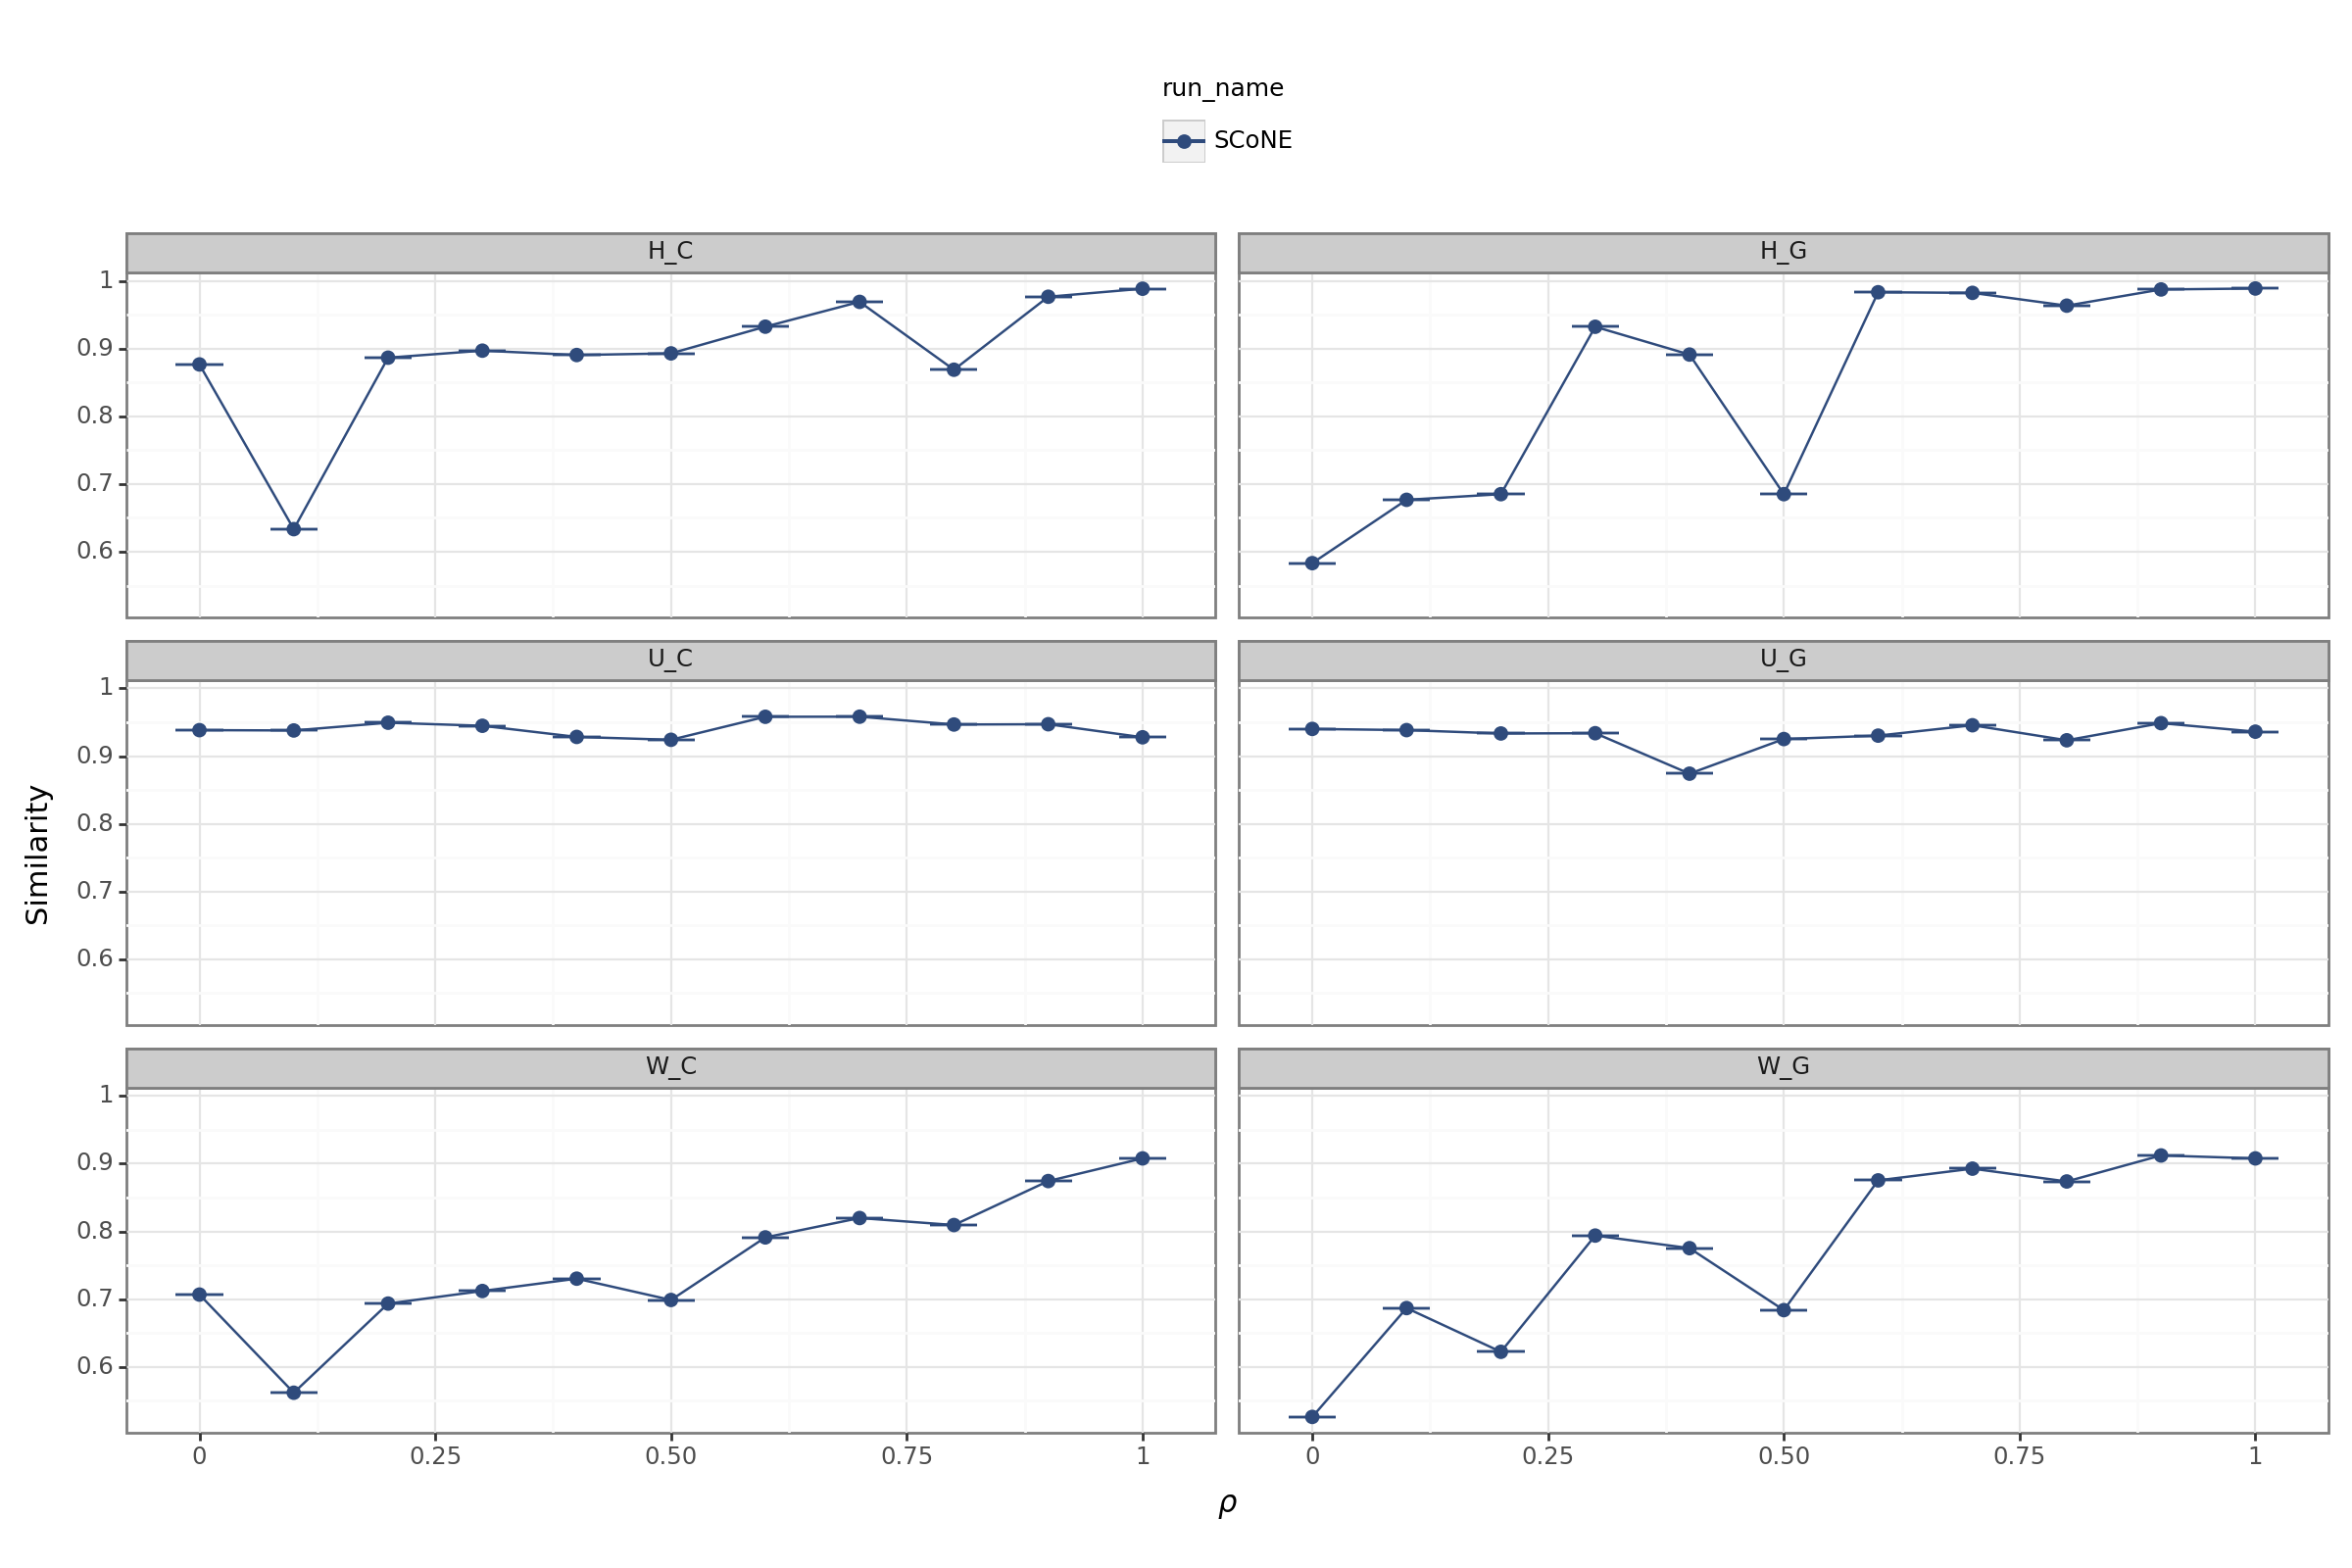

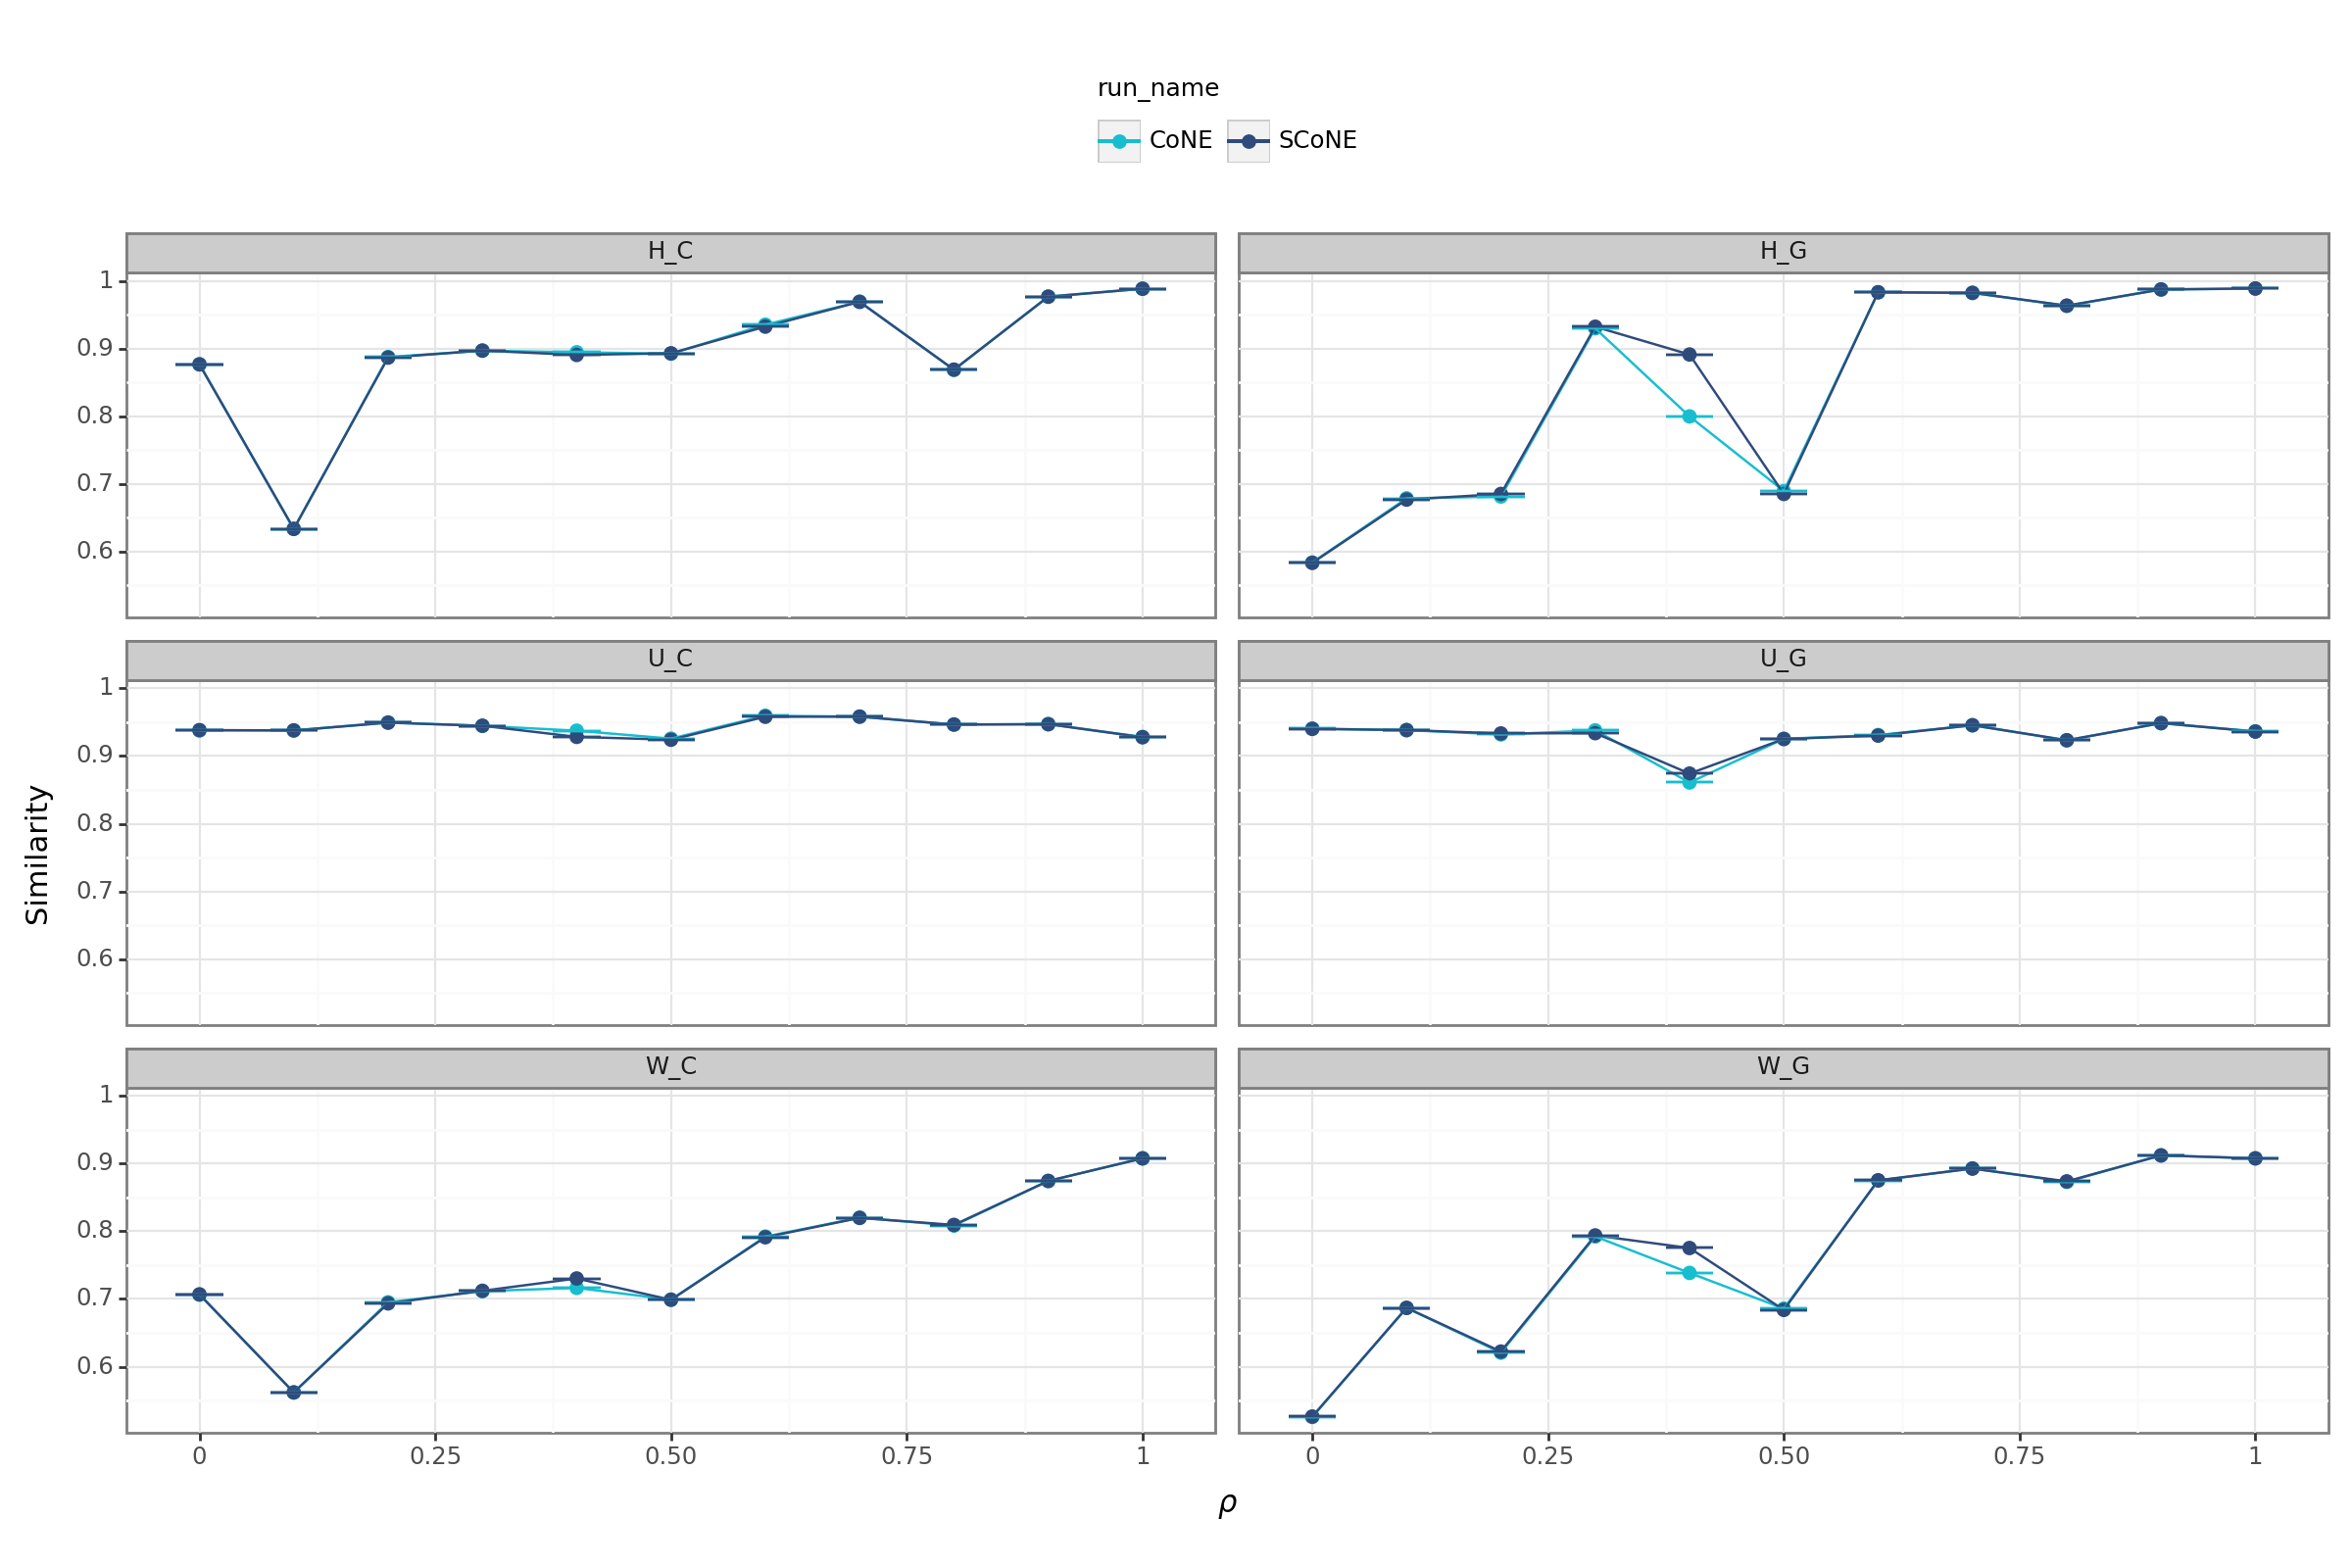

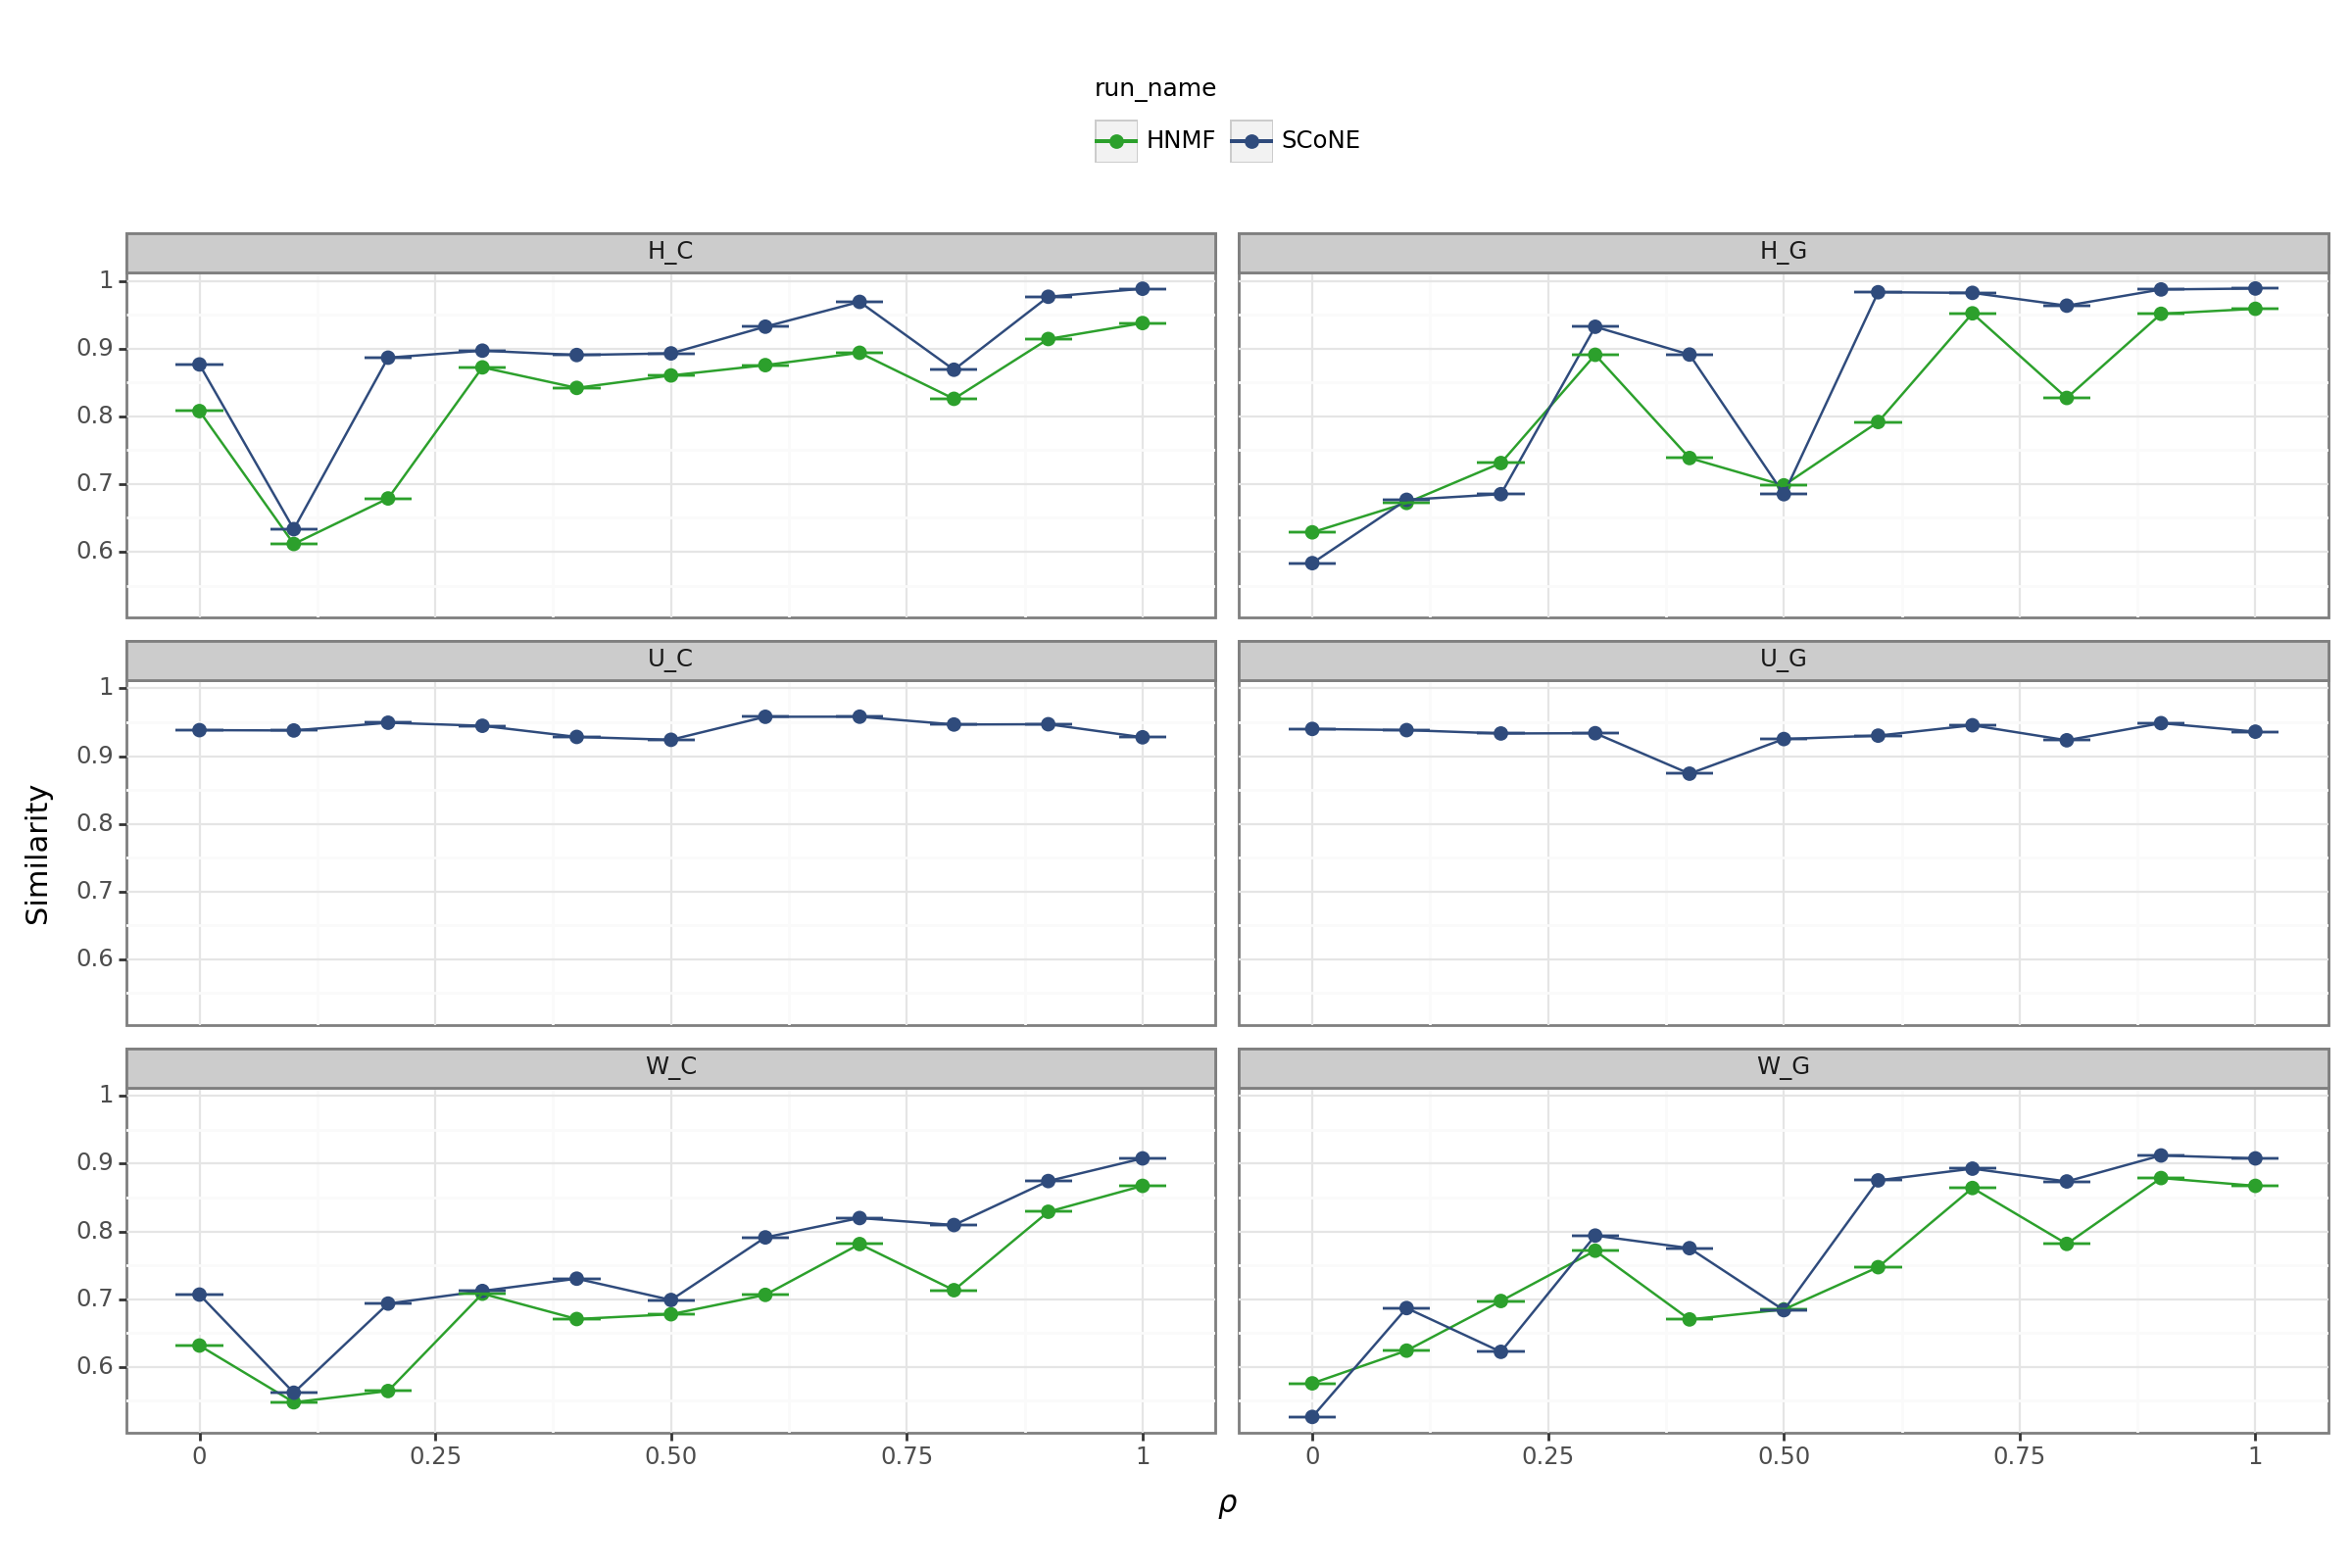

In [3]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/rho_summary.csv',index_col=0)
summary = summary[~((summary['run_name']=='HNMF')&(summary['factor_matrix'].str.startswith('U')))]
graph_plots(summary,"rho",r'$\rho$')

# Assess runs over ZU weight

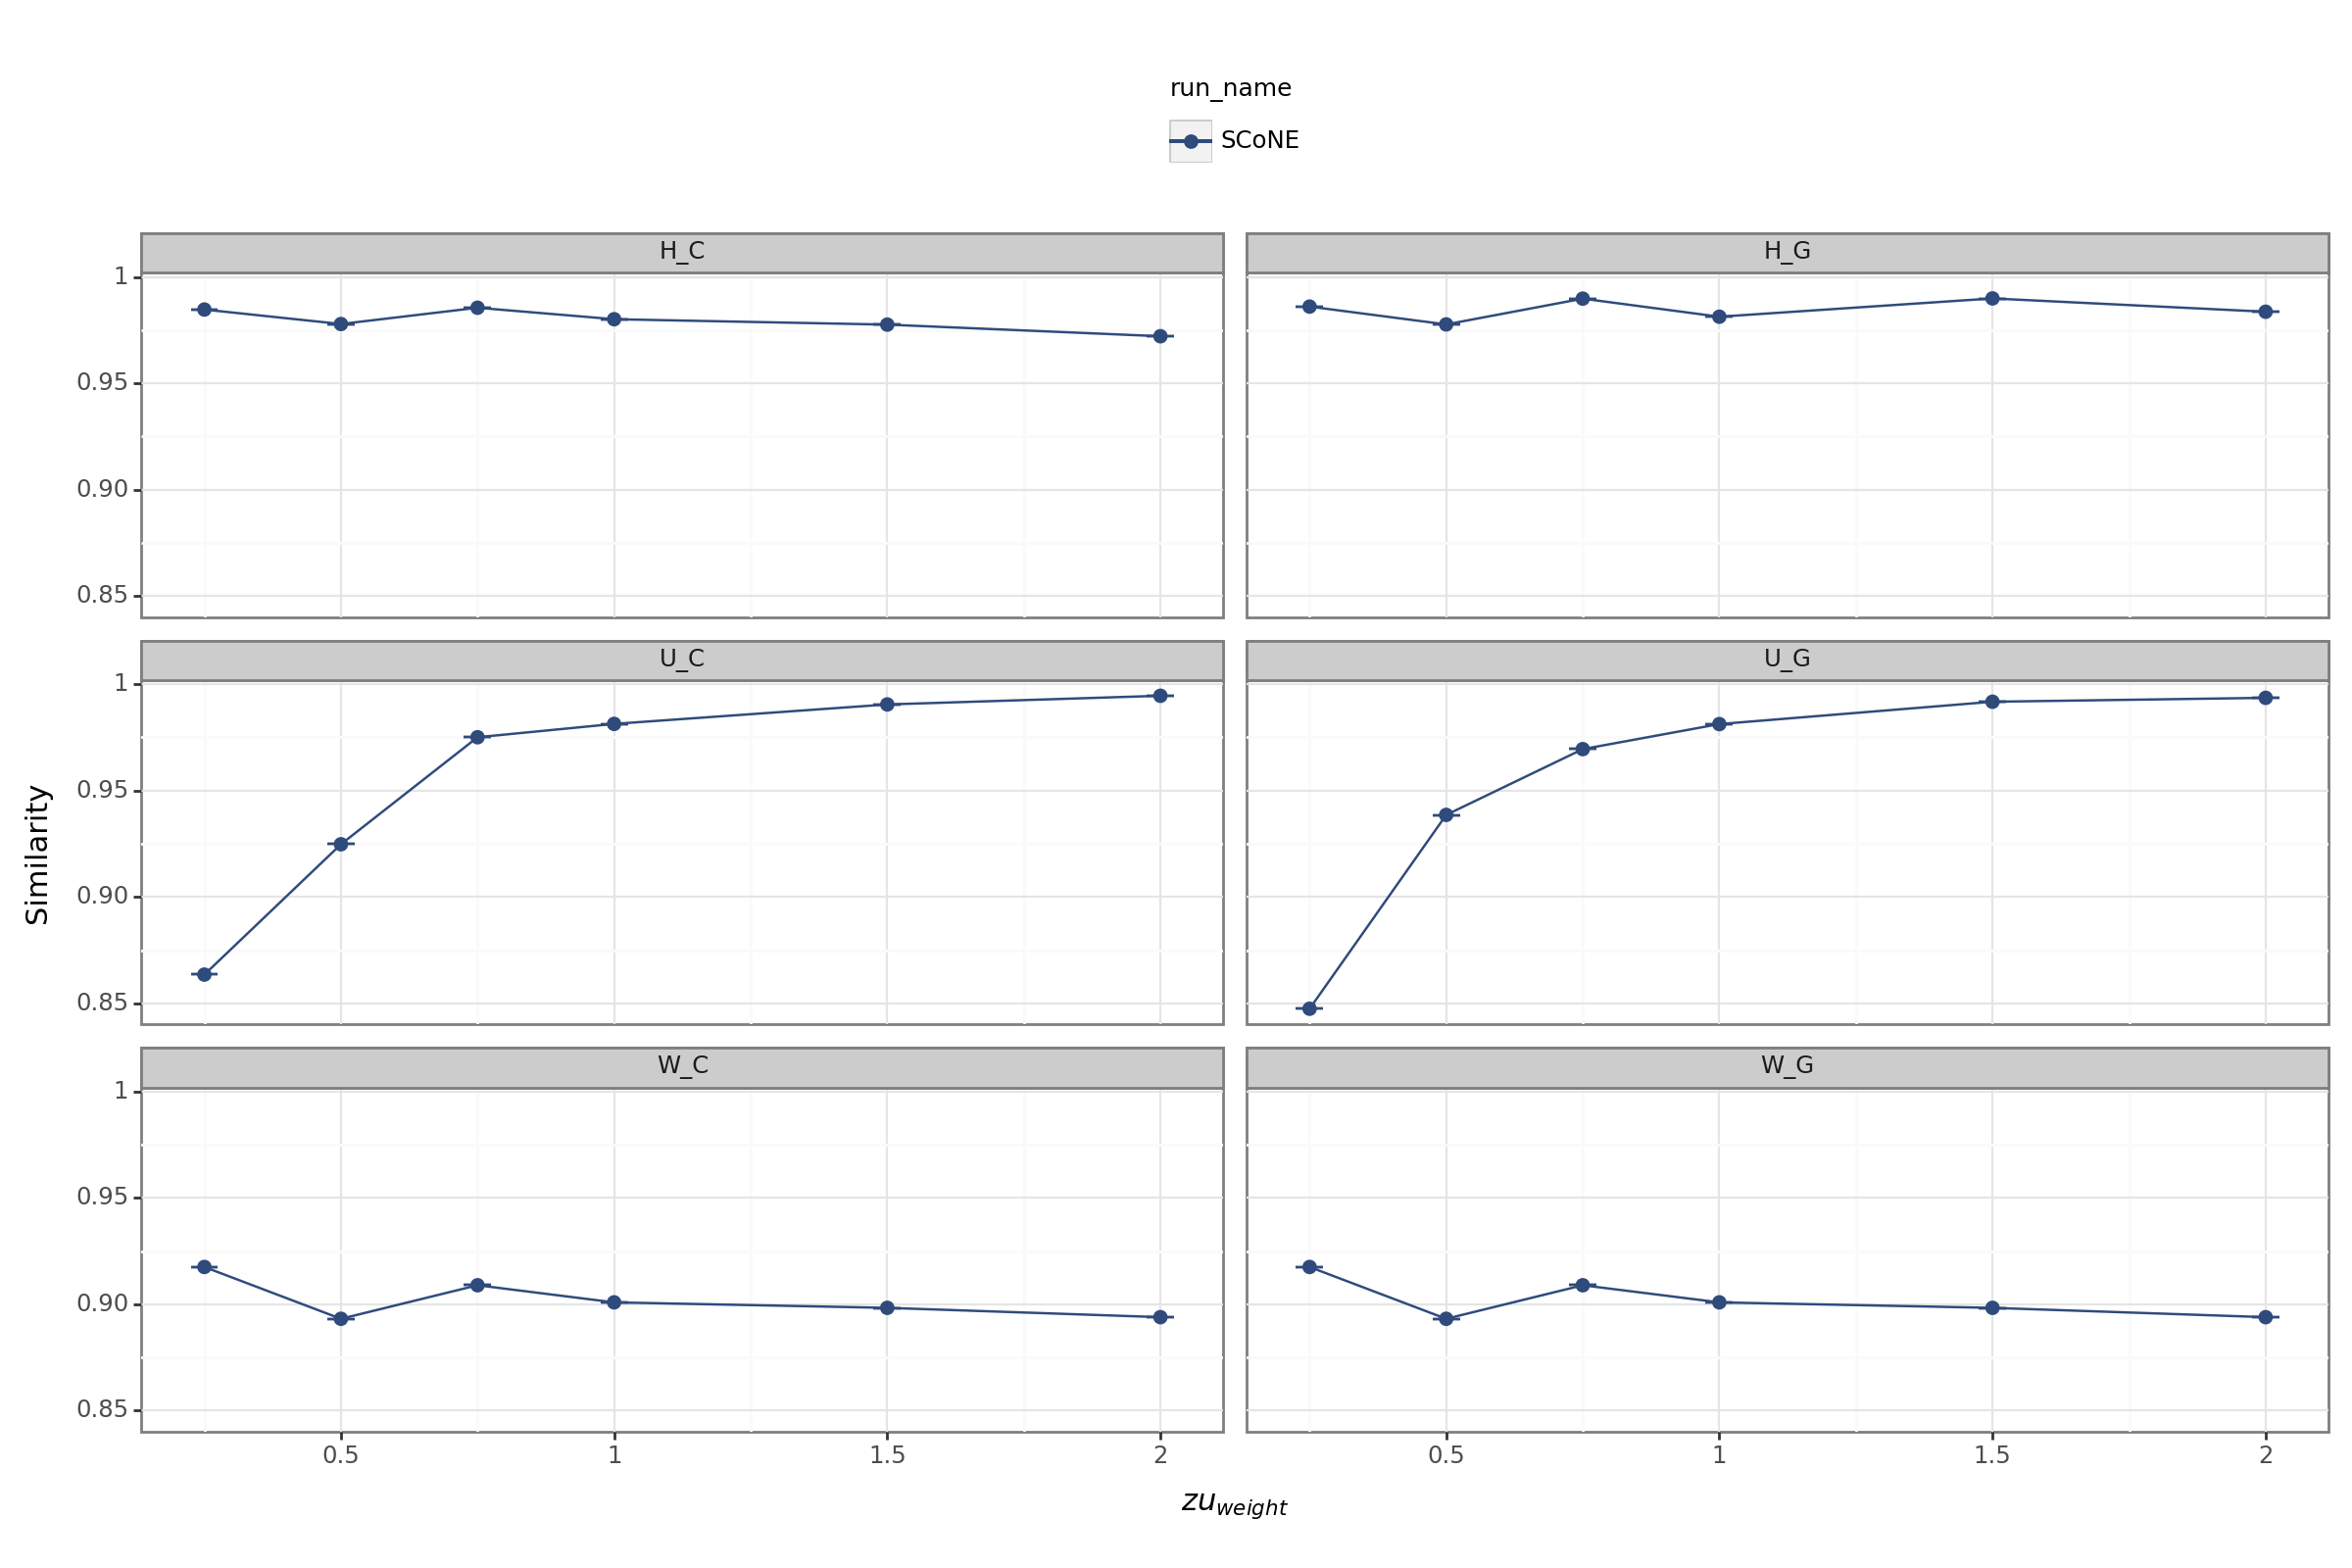

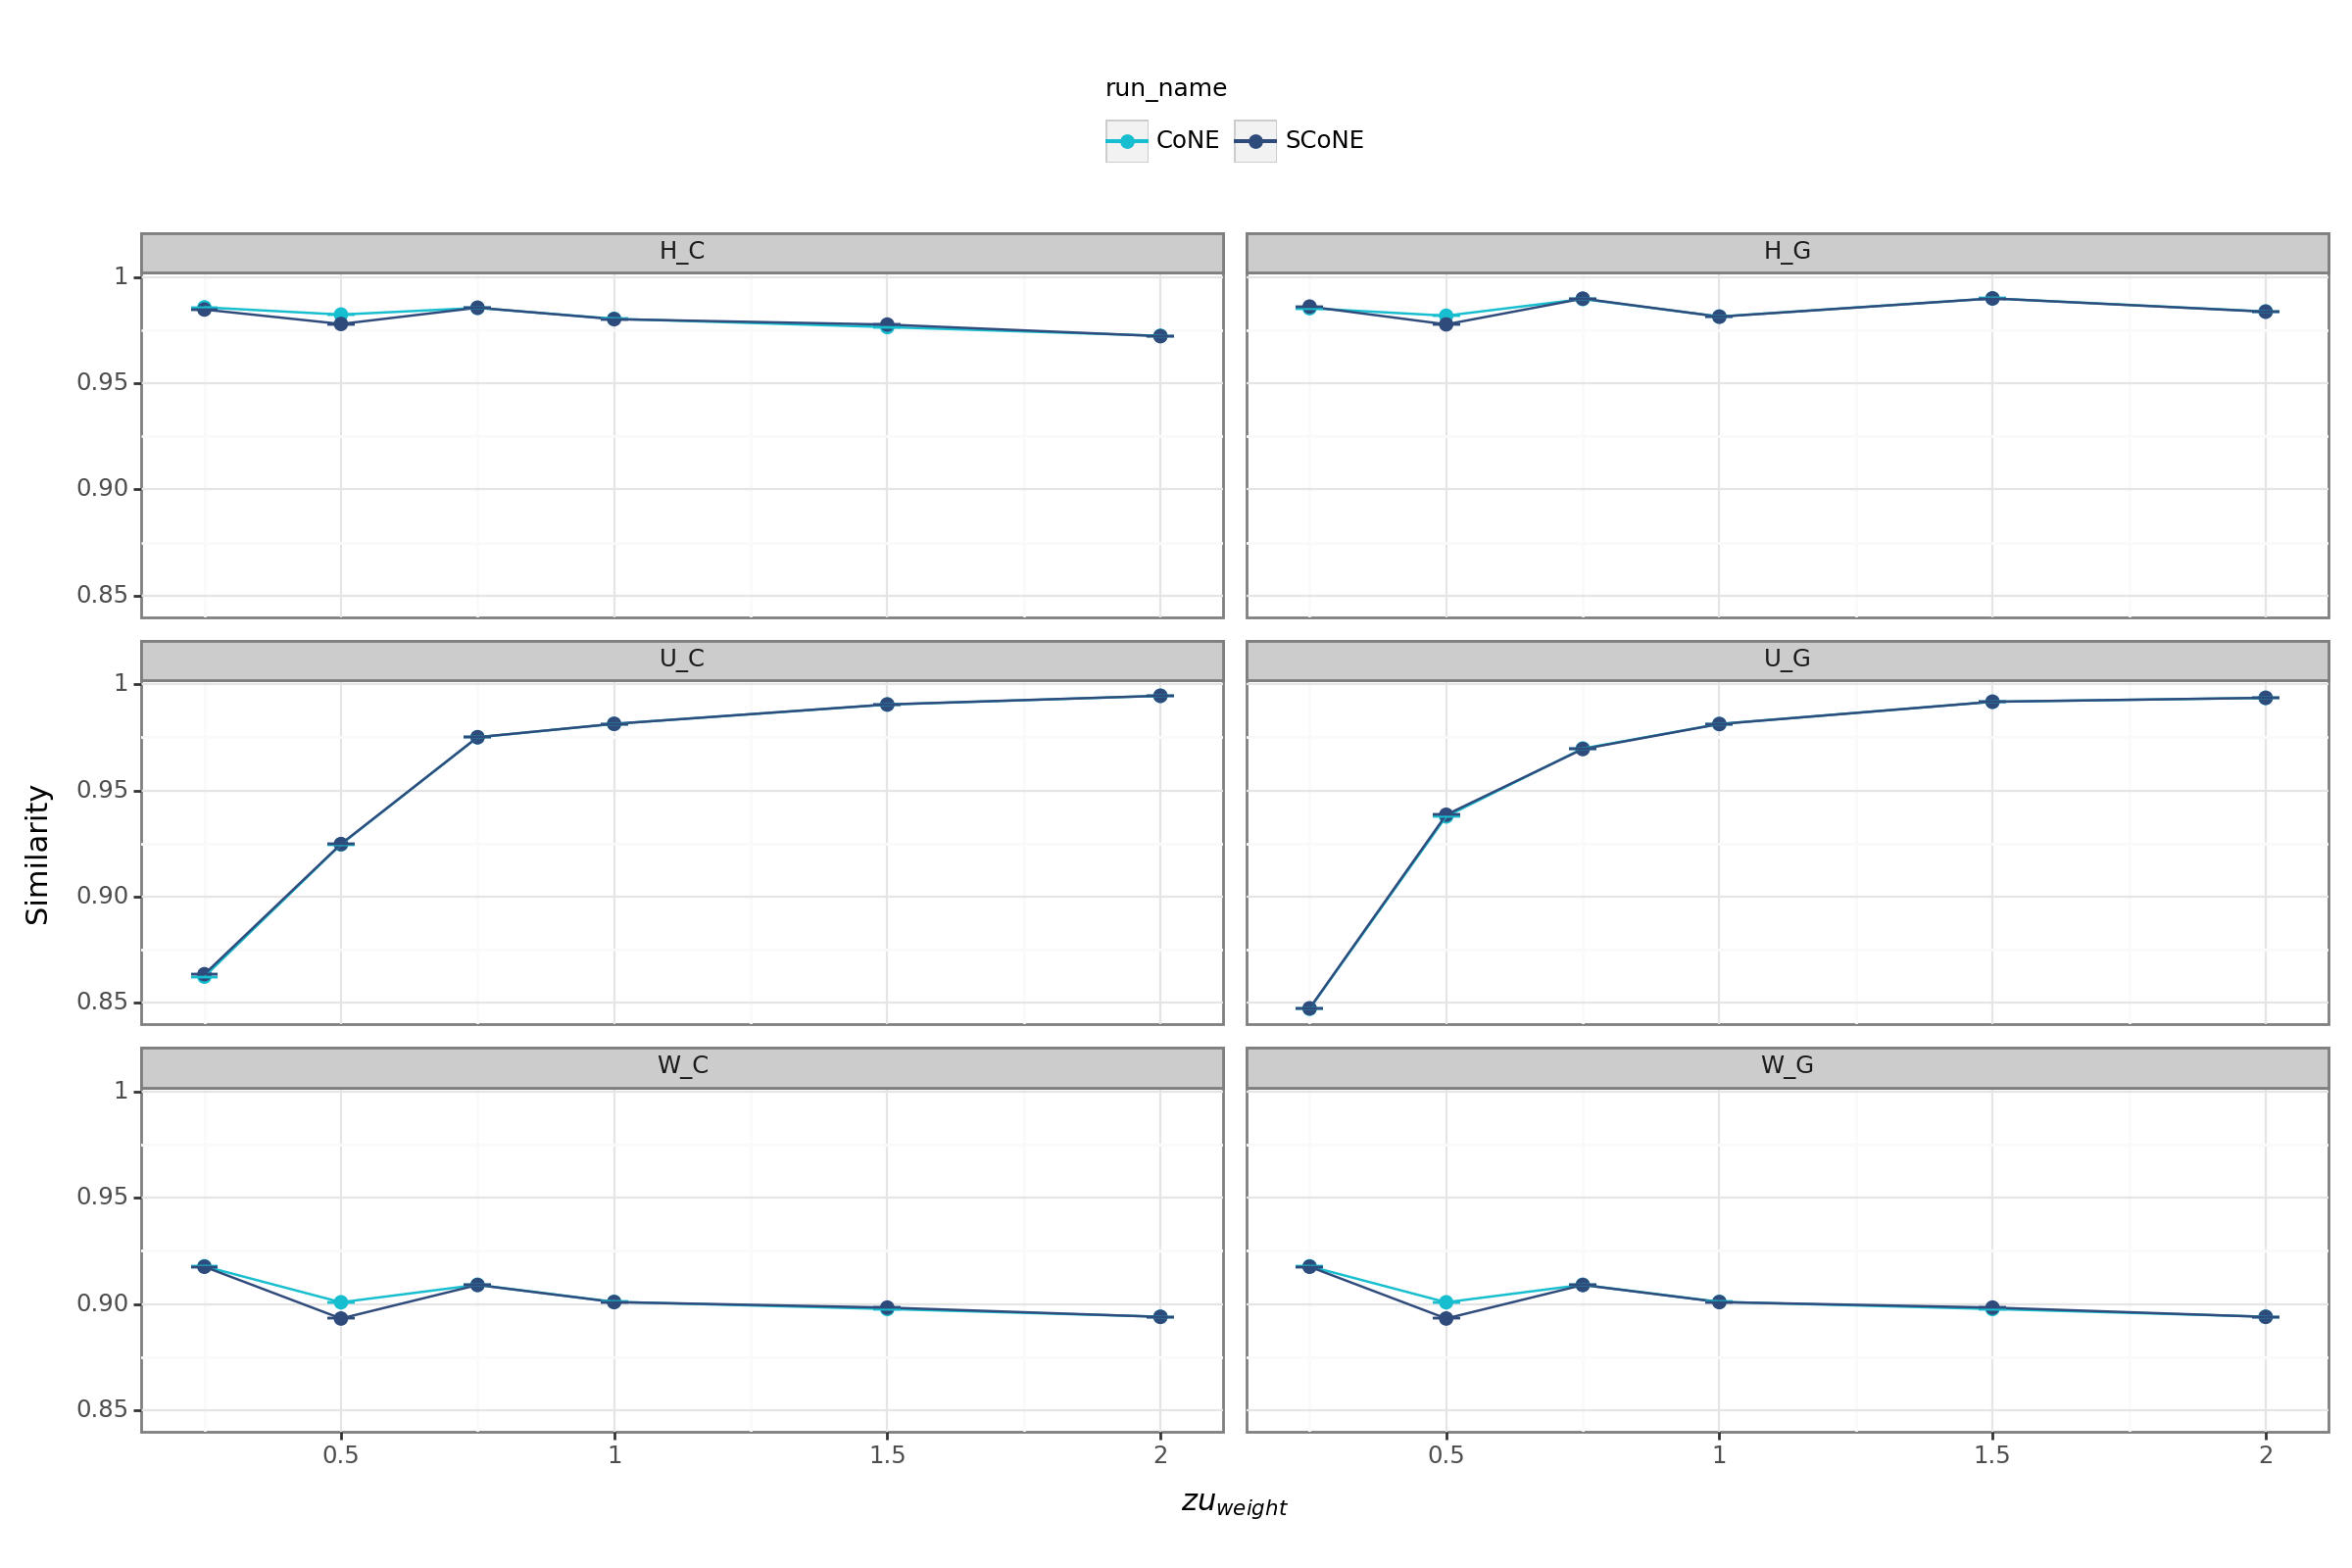

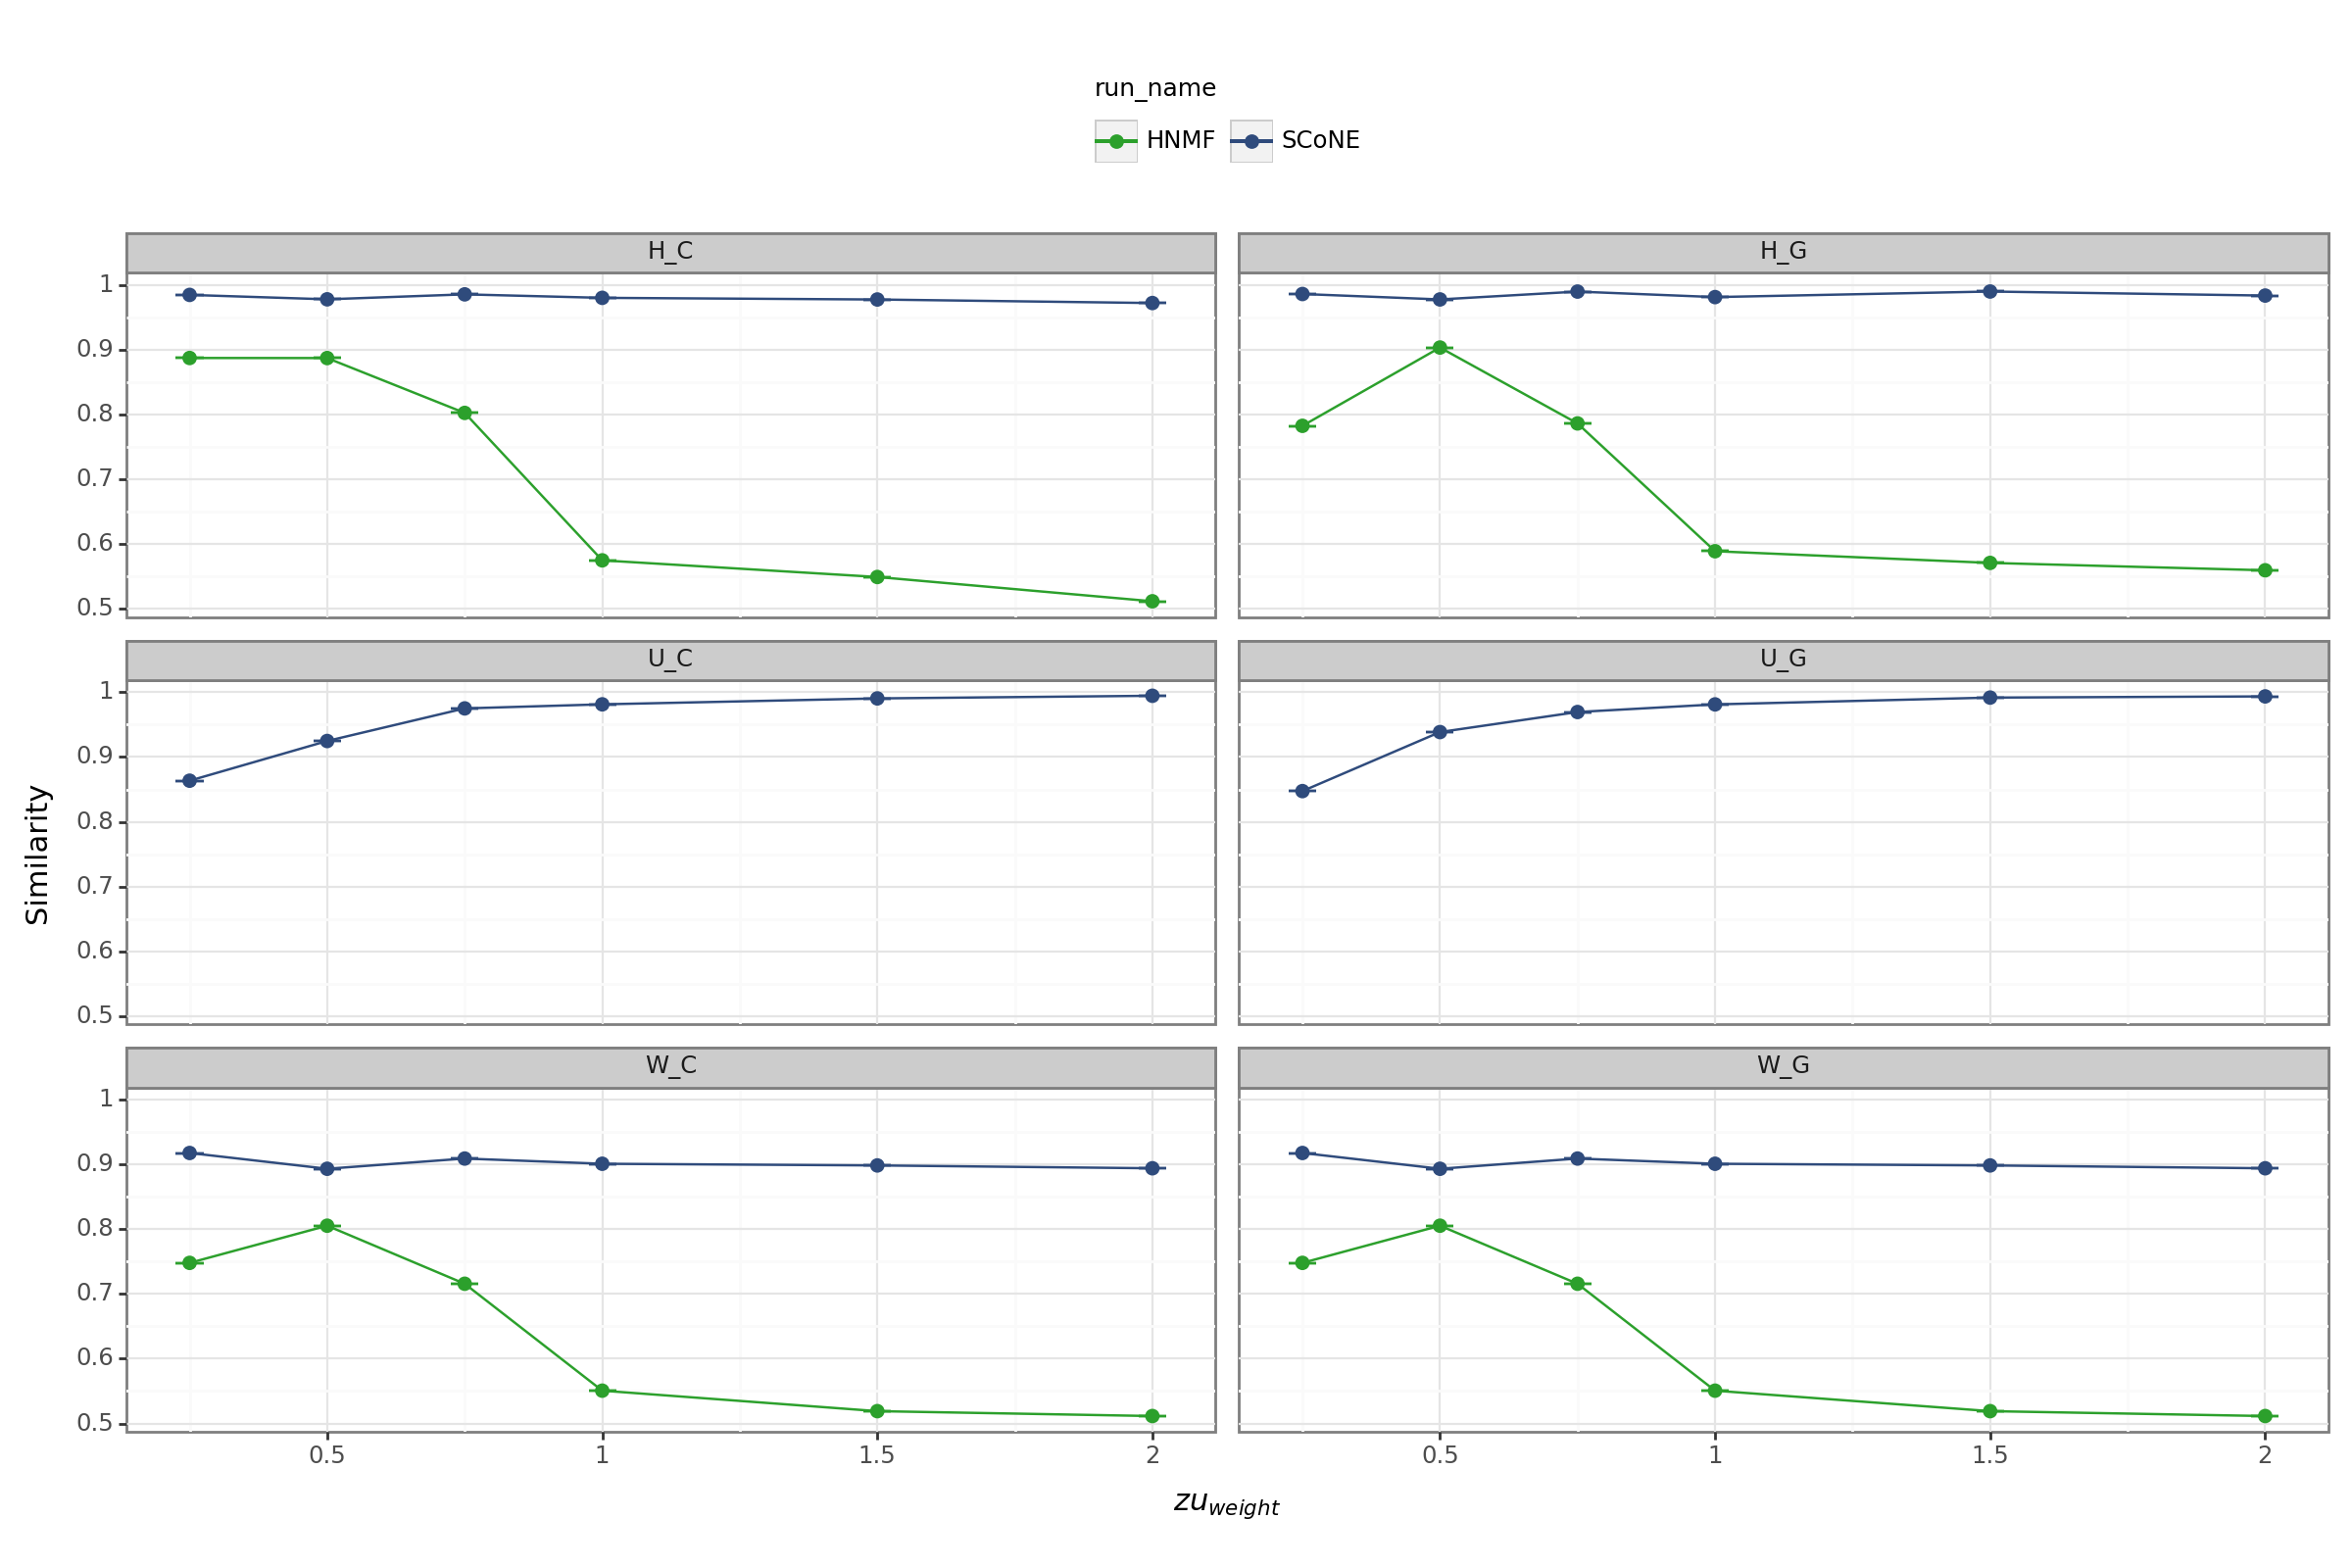

In [4]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/zu_weight_summary.csv',index_col=0)
summary = summary[~((summary['run_name']=='HNMF')&(summary['factor_matrix'].str.startswith('U')))]
graph_plots(summary,"ZU_weight",r'$zu_{weight}$')

# Assess runs over noise

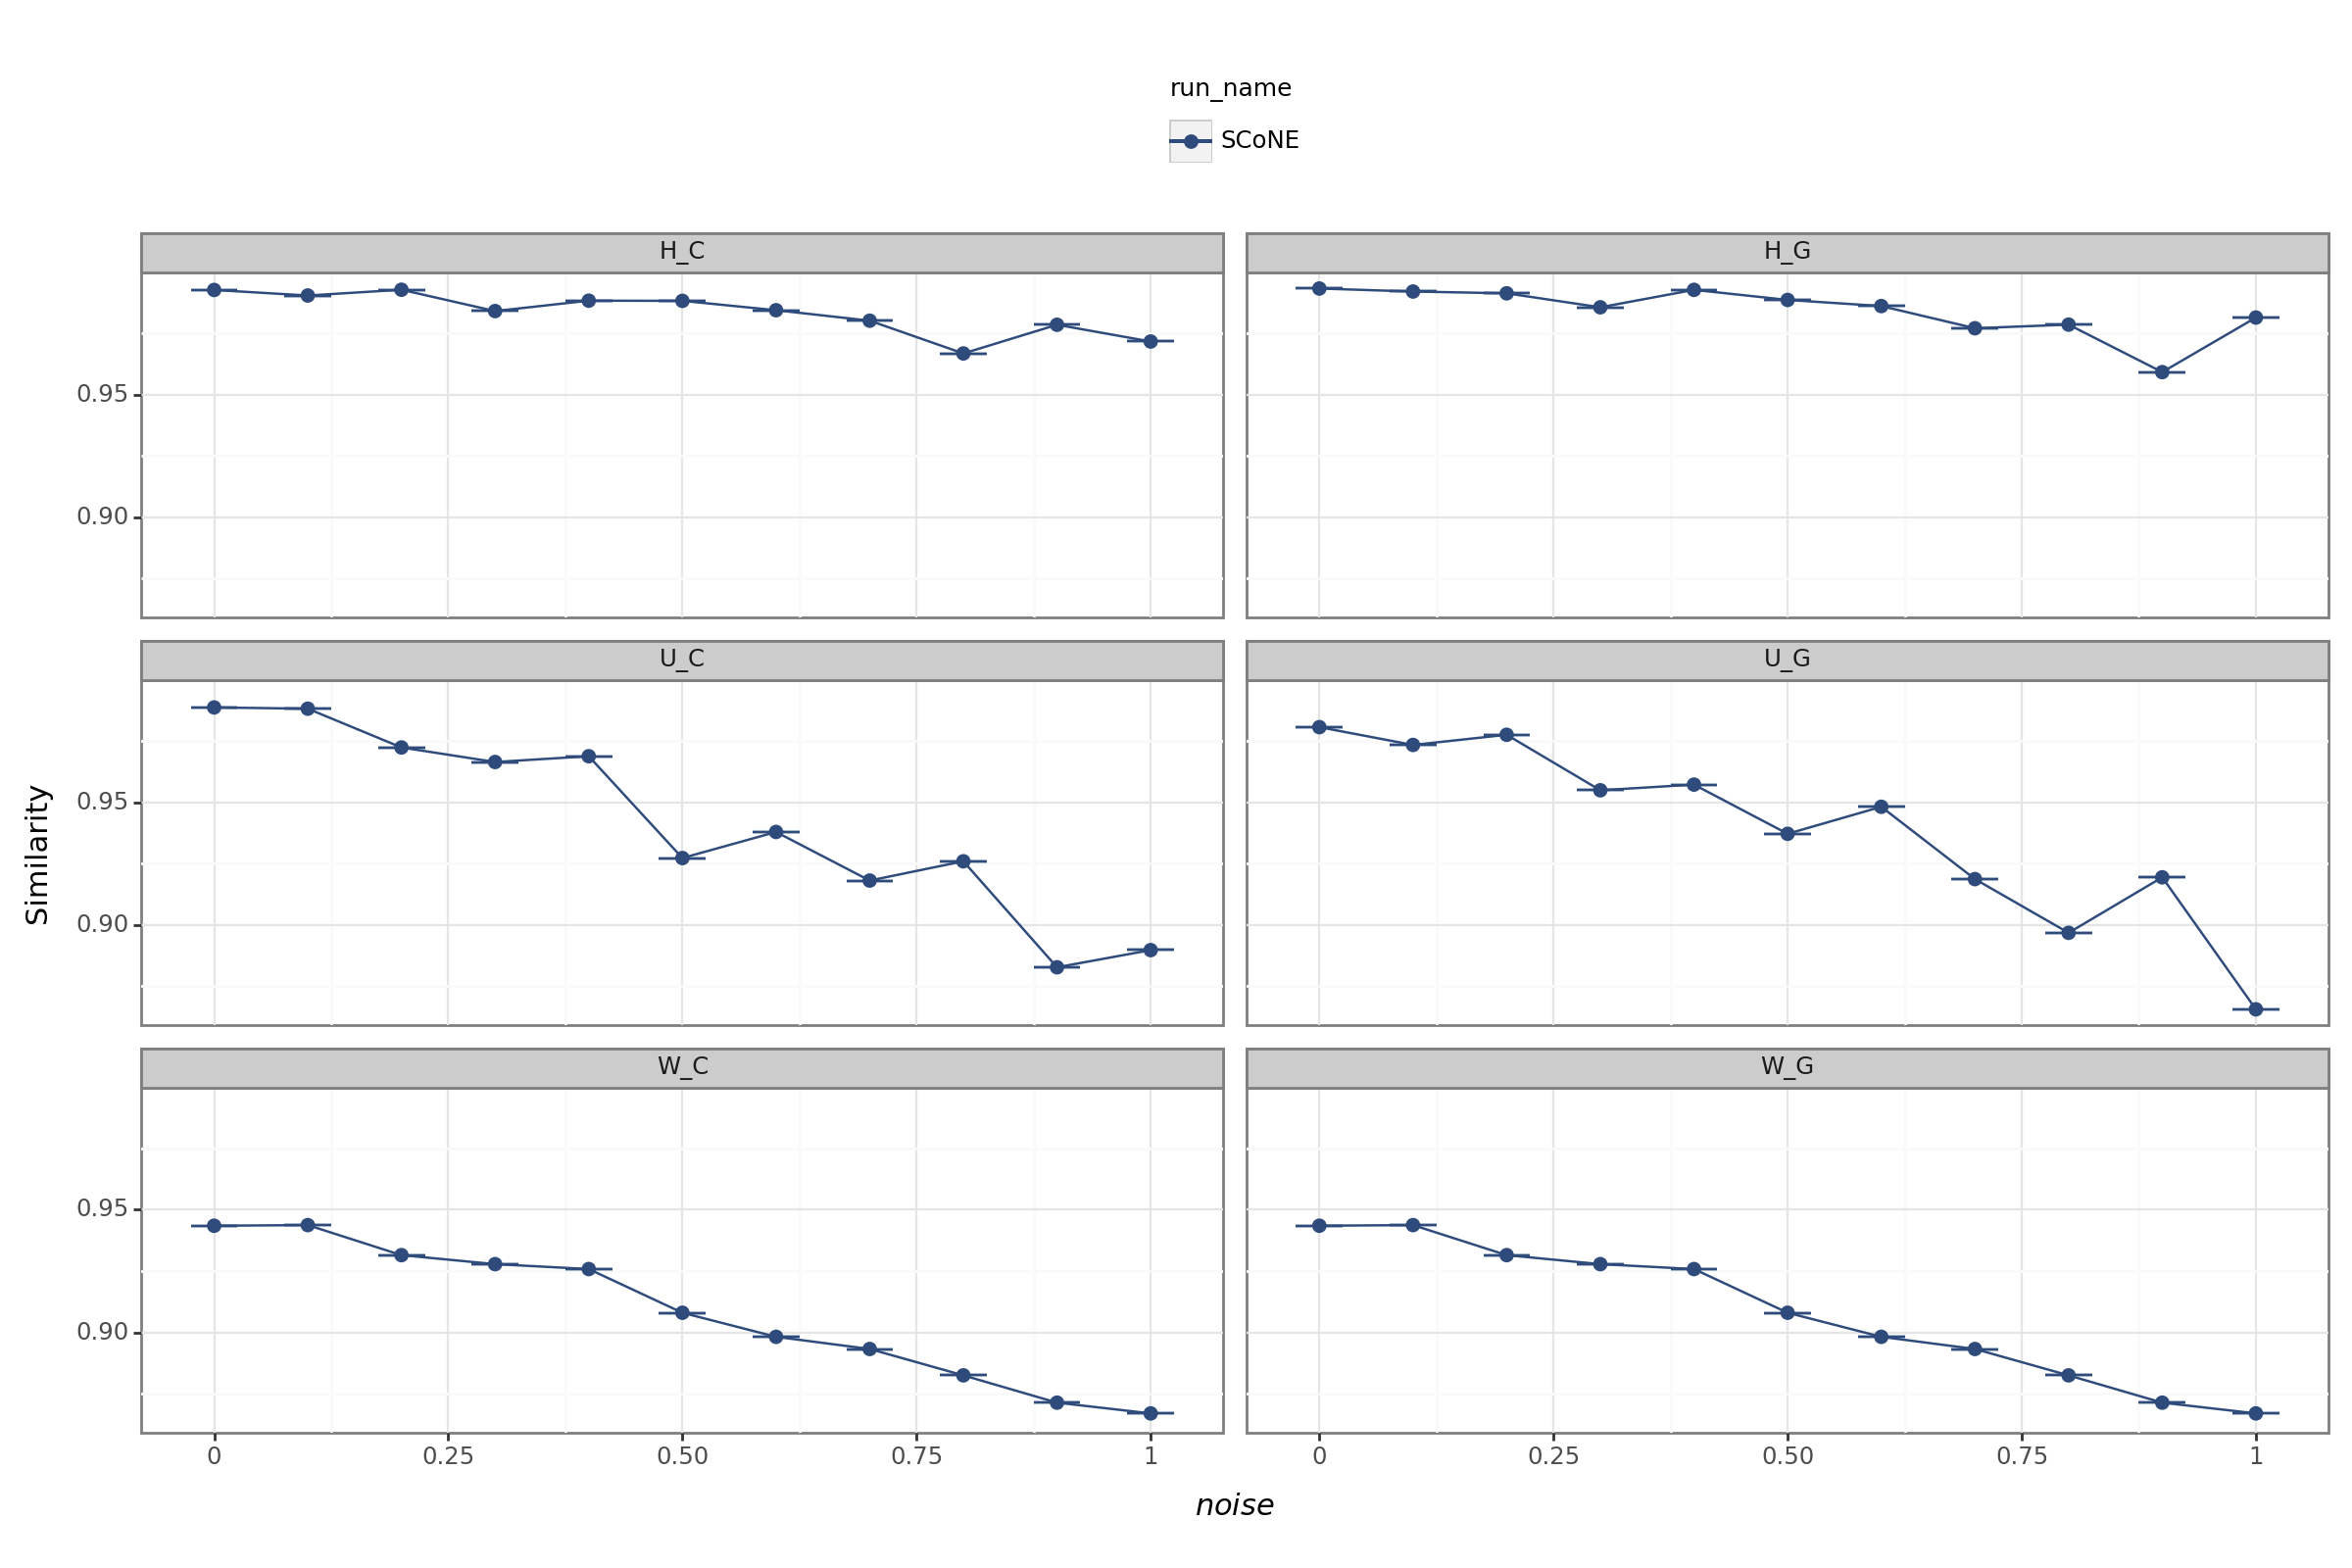

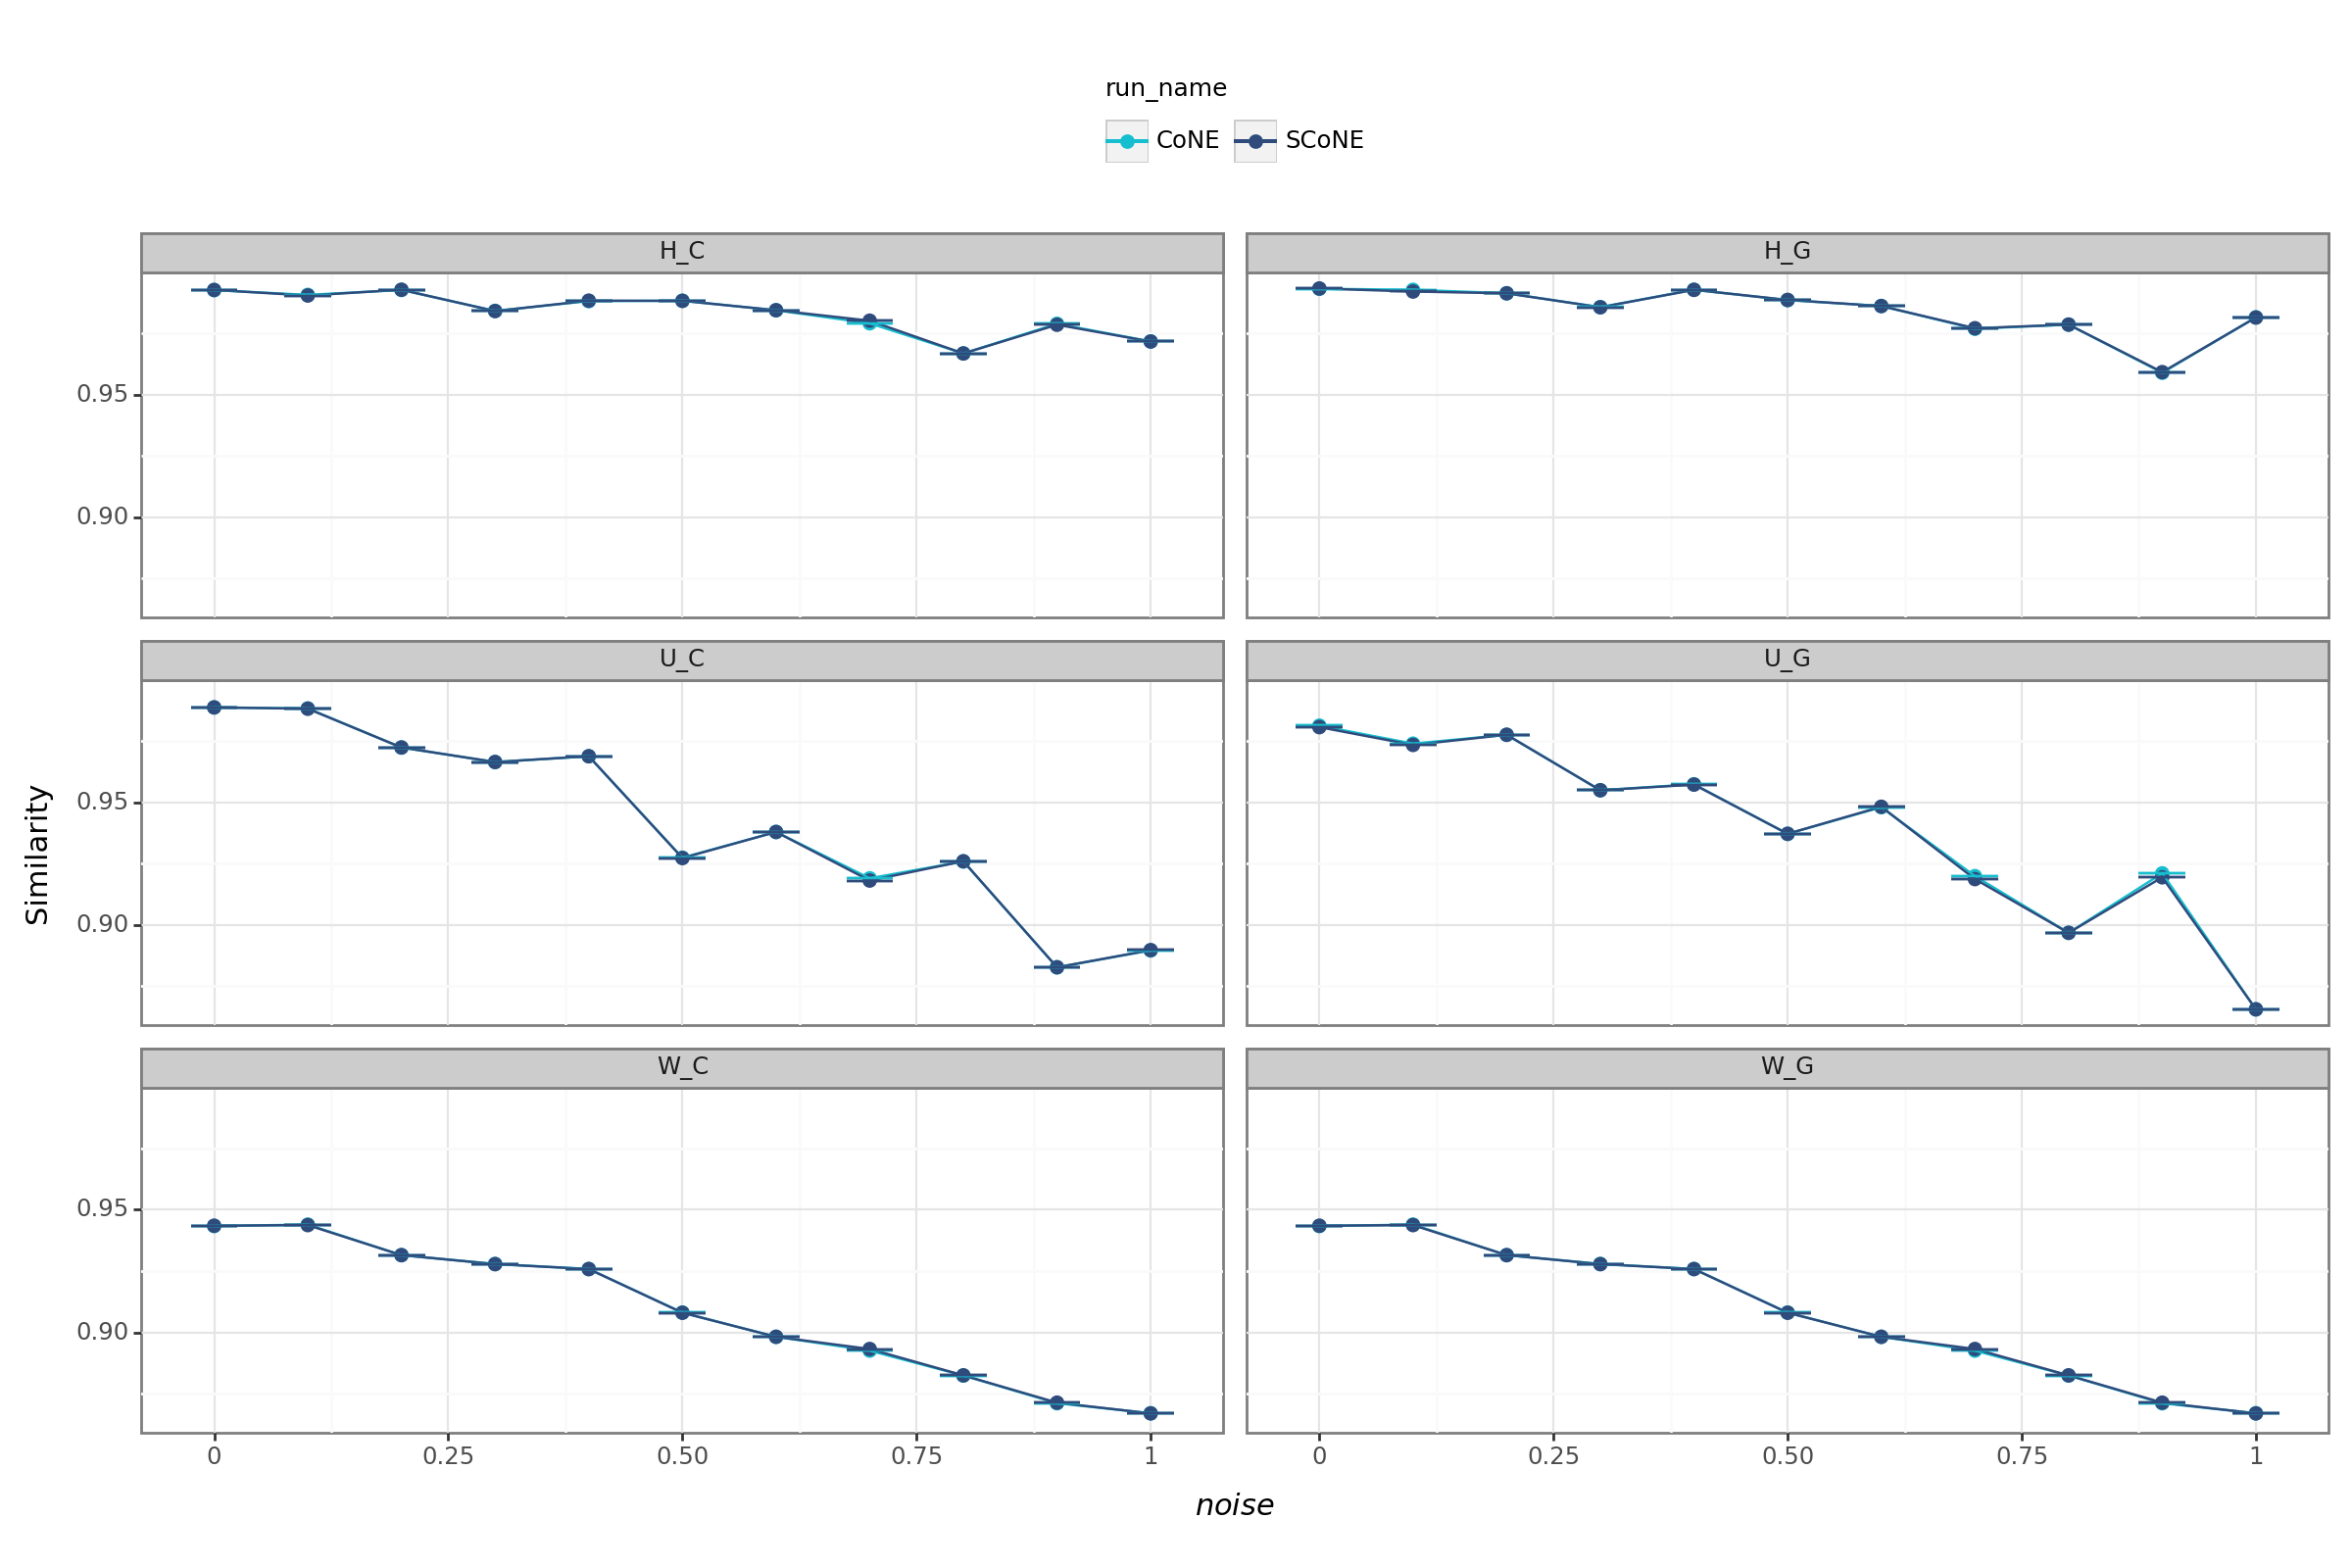

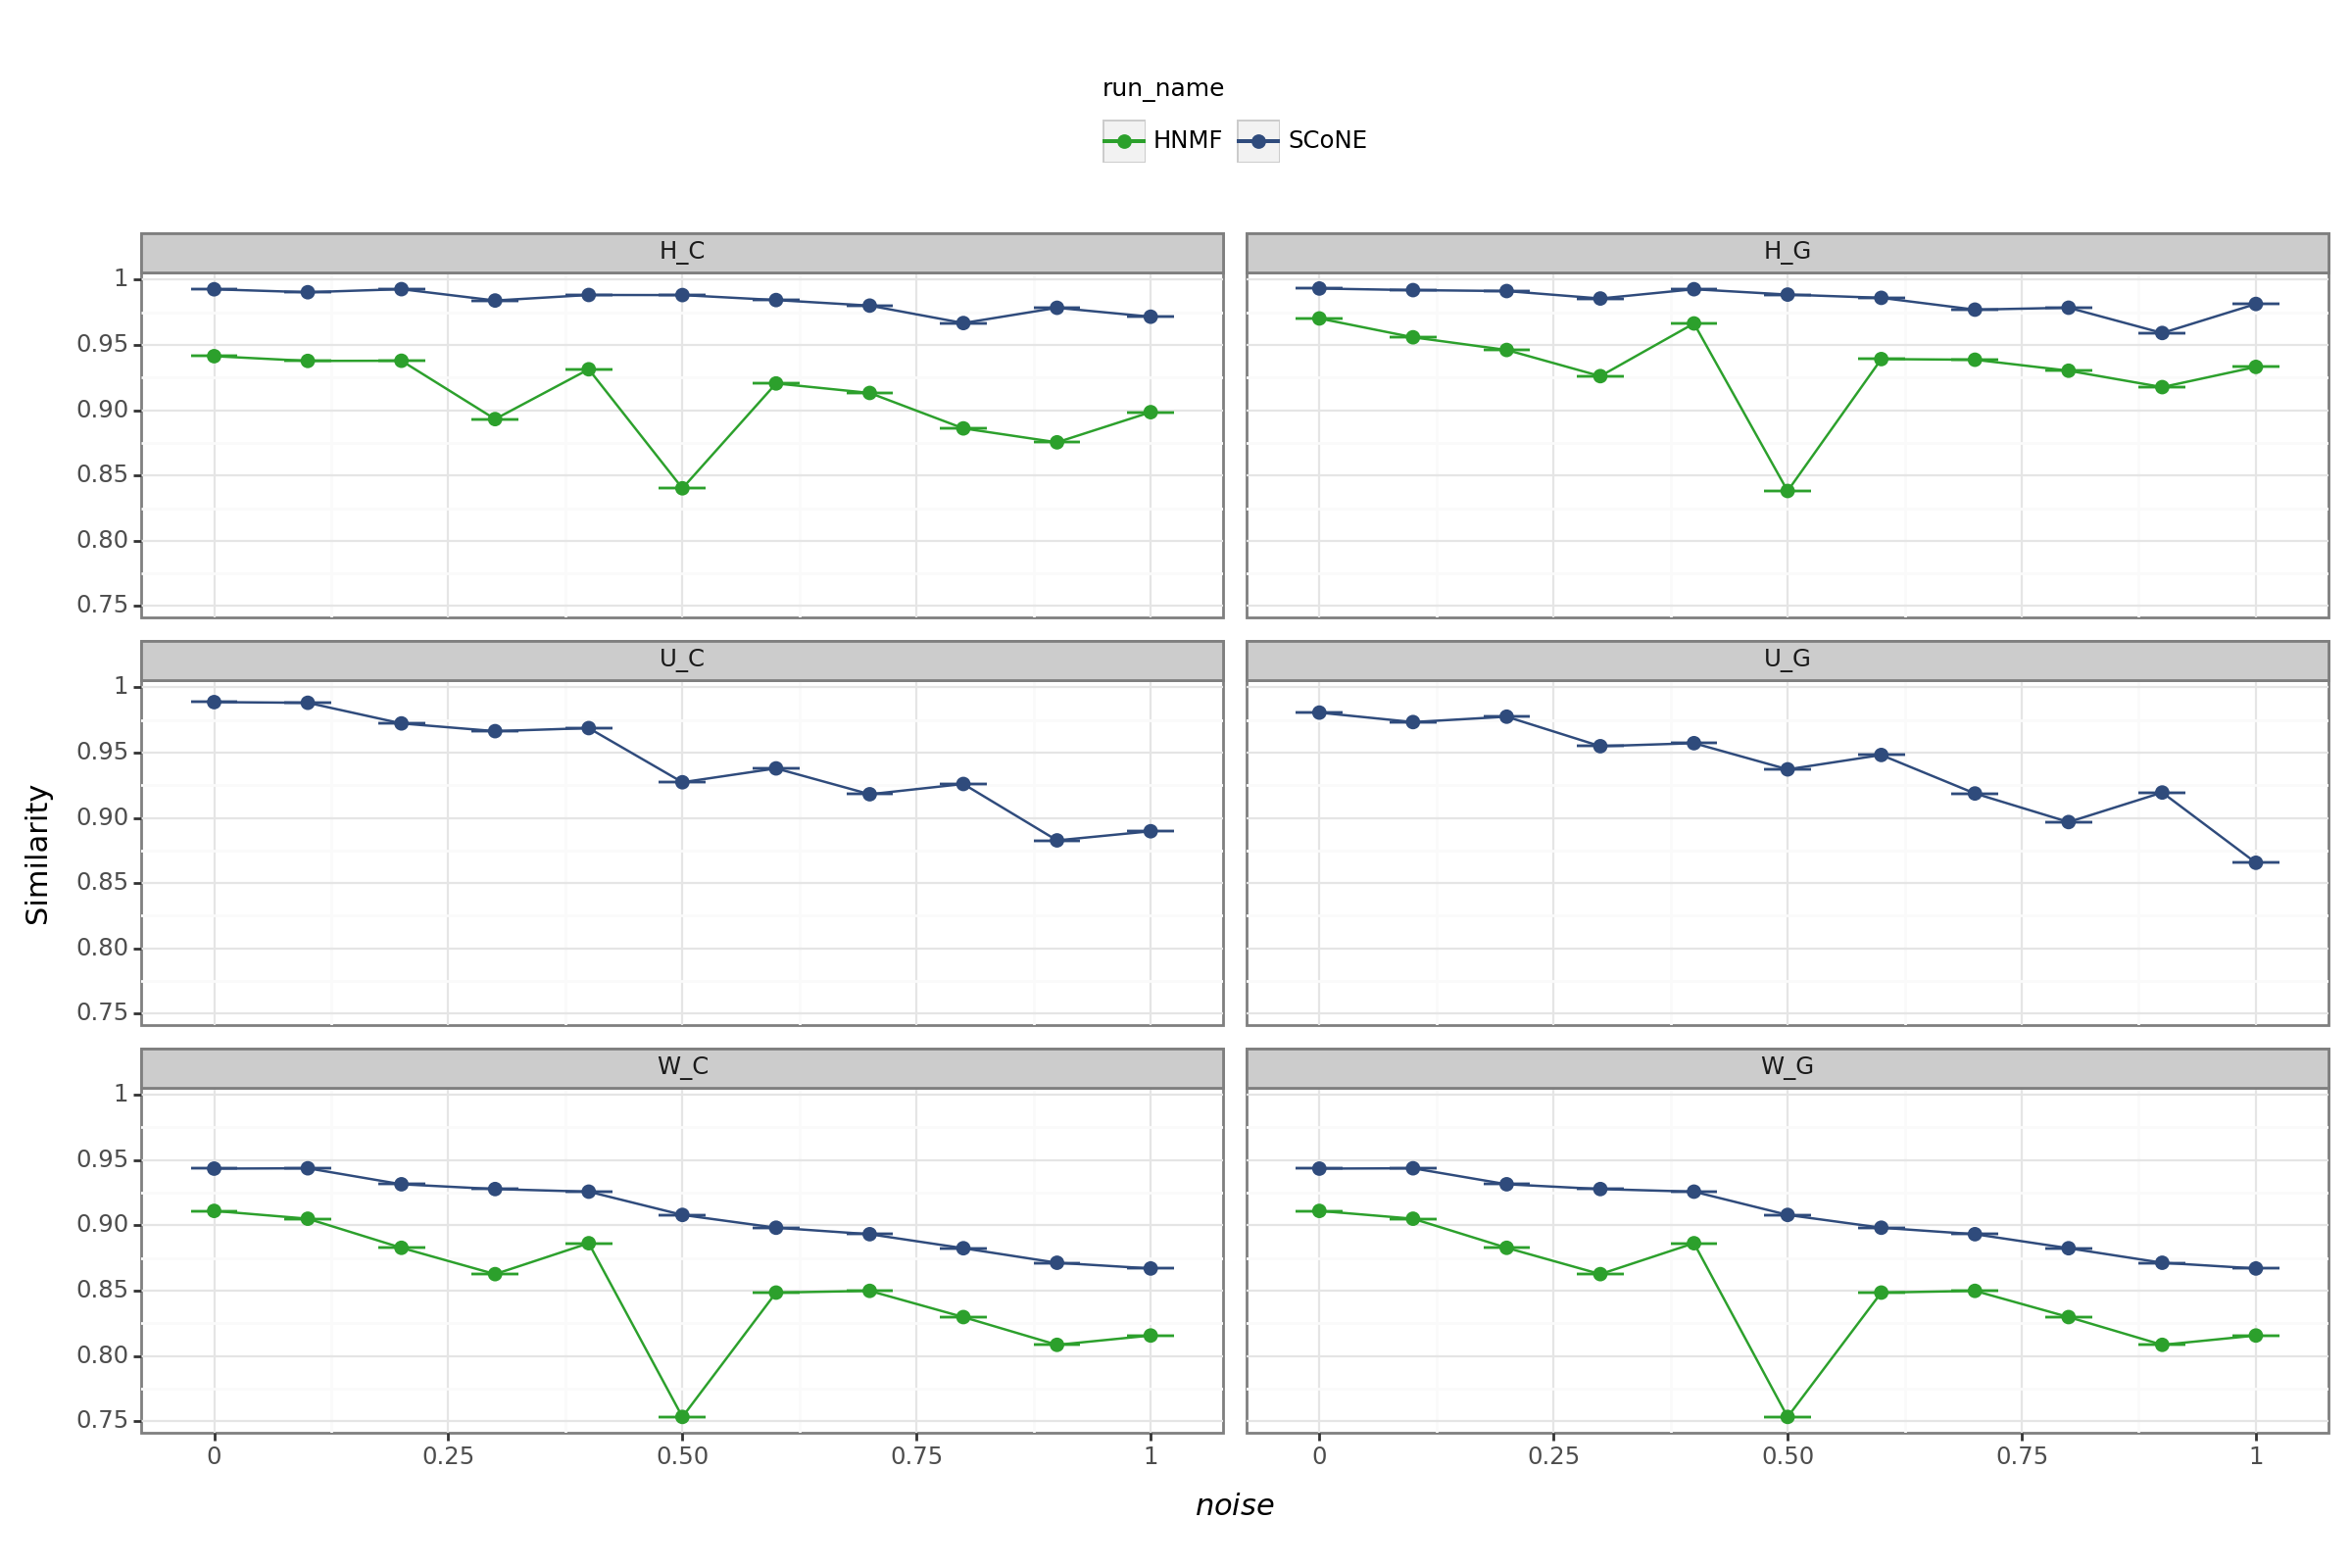

In [5]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/noise_summary.csv',index_col=0)
summary = summary[~((summary['run_name']=='HNMF')&(summary['factor_matrix'].str.startswith('U')))]
graph_plots(summary,"noise",r'$noise$')

# Assess runs over sparsity

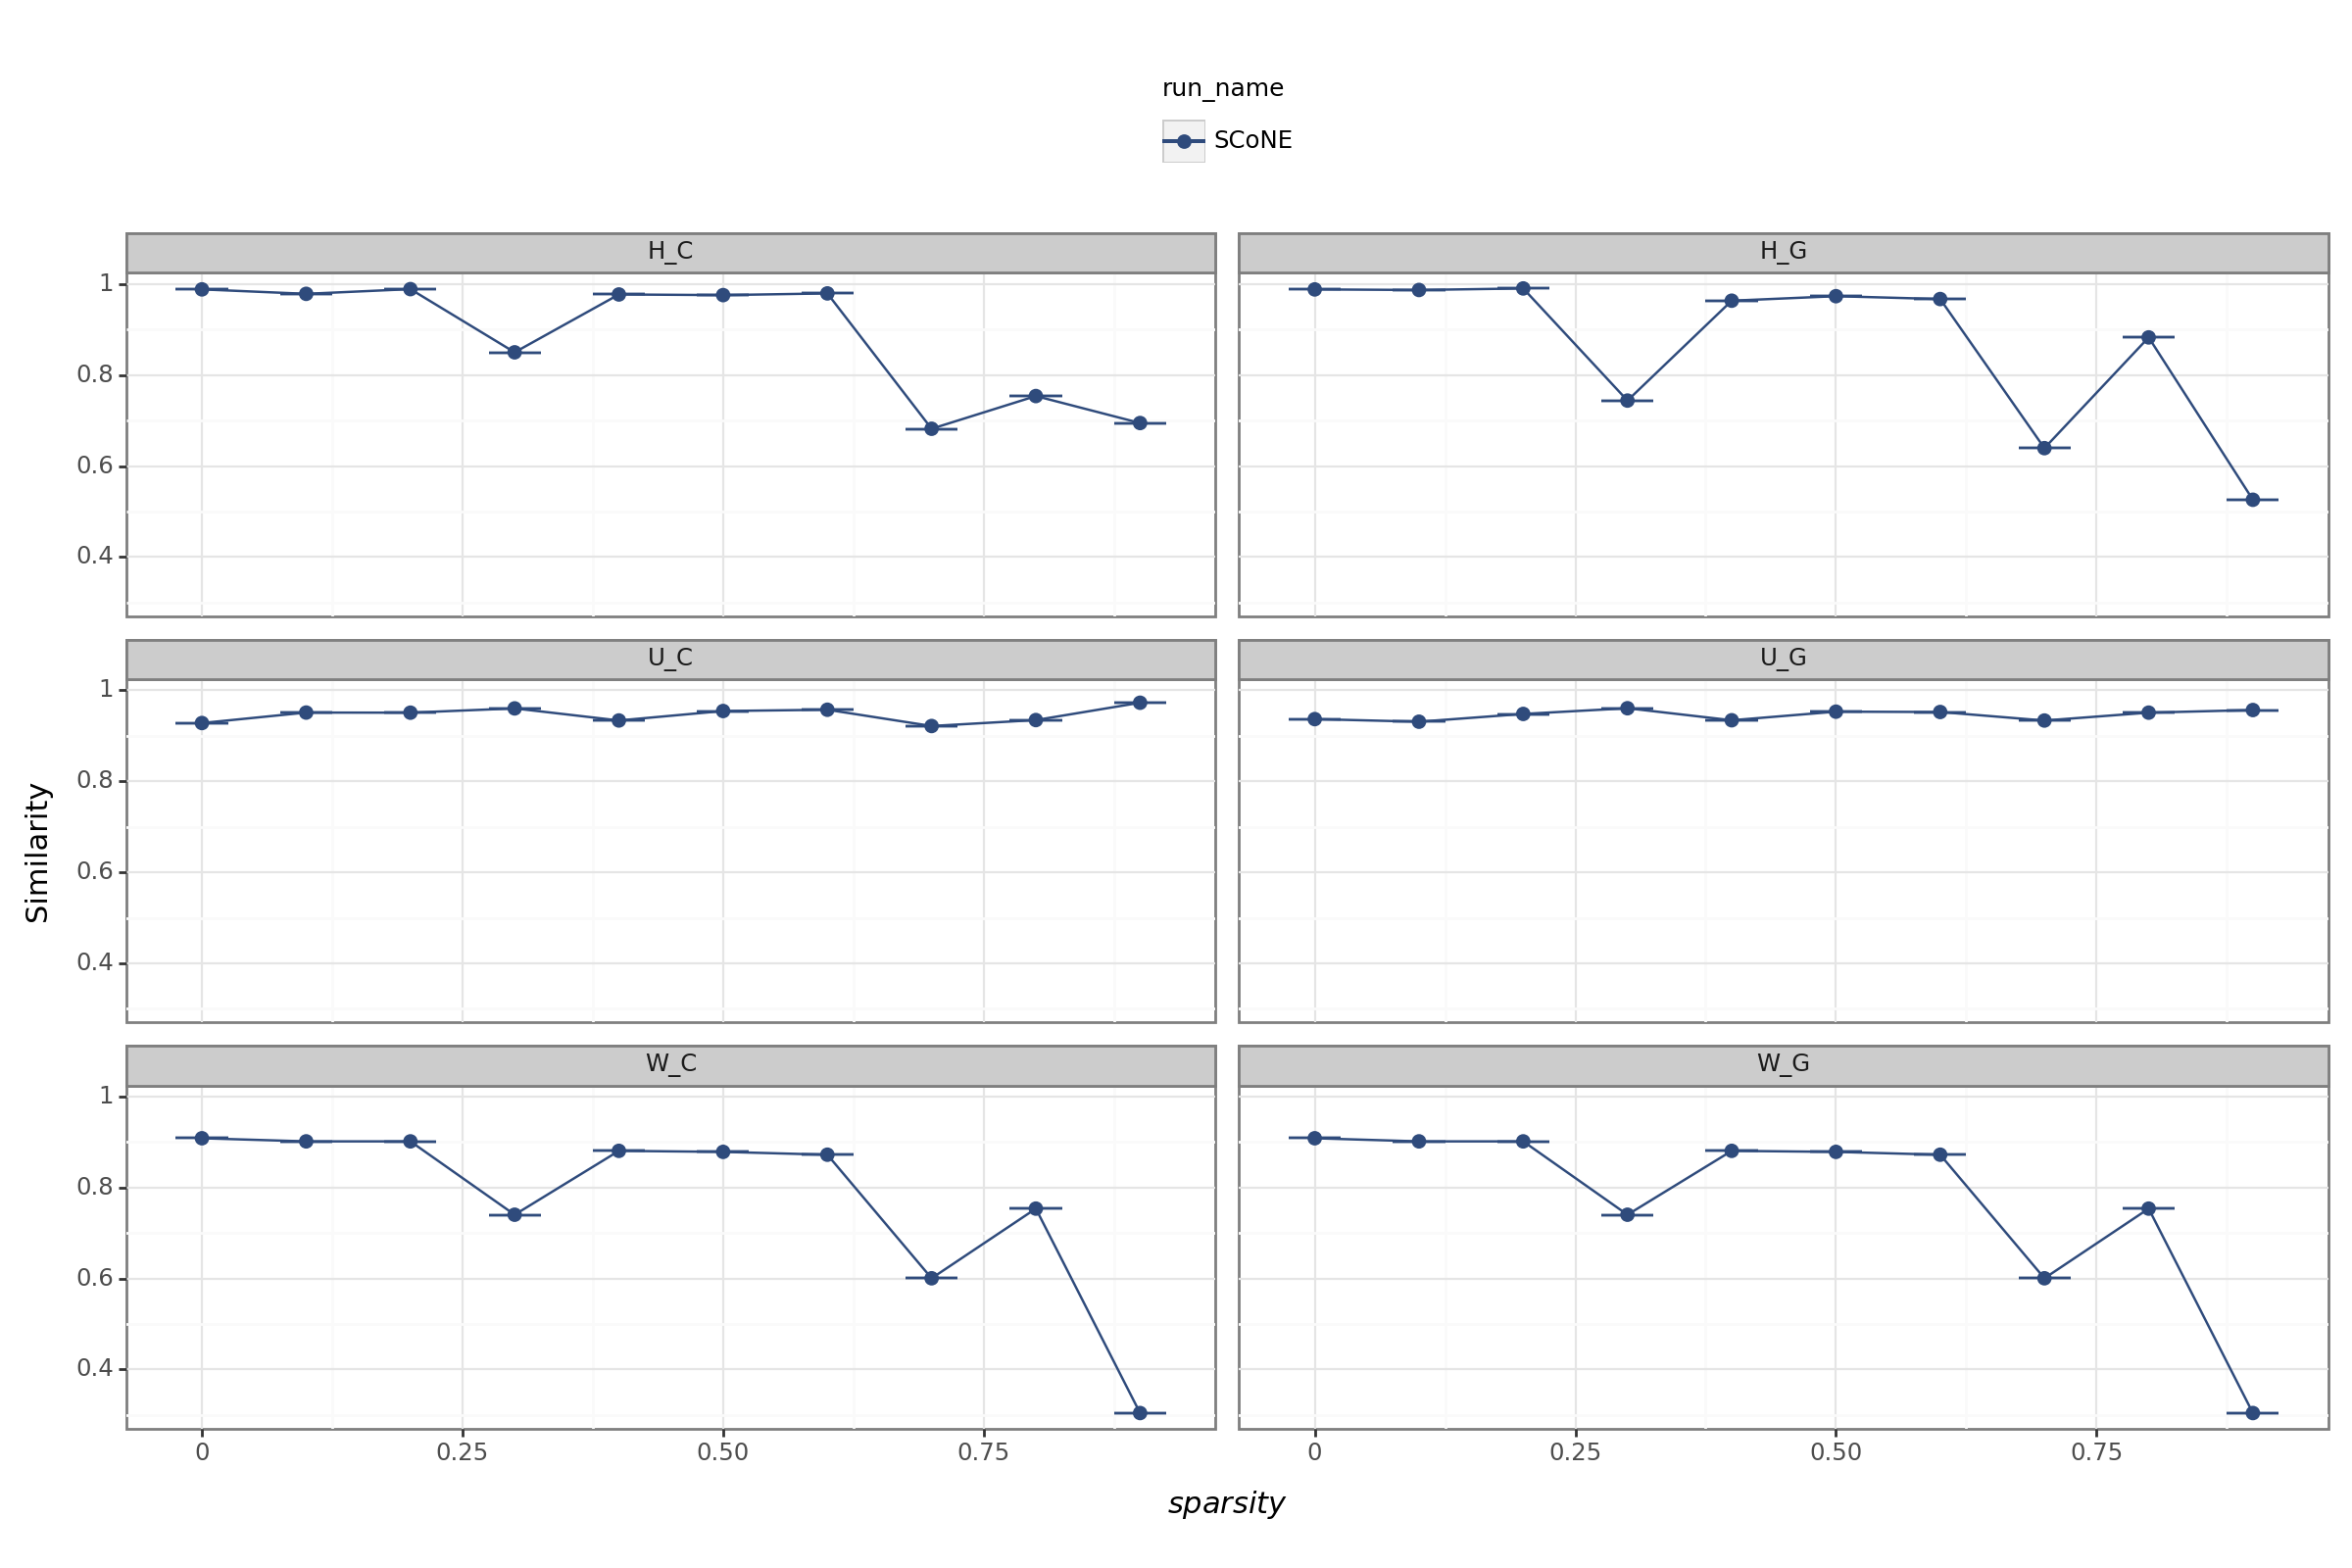

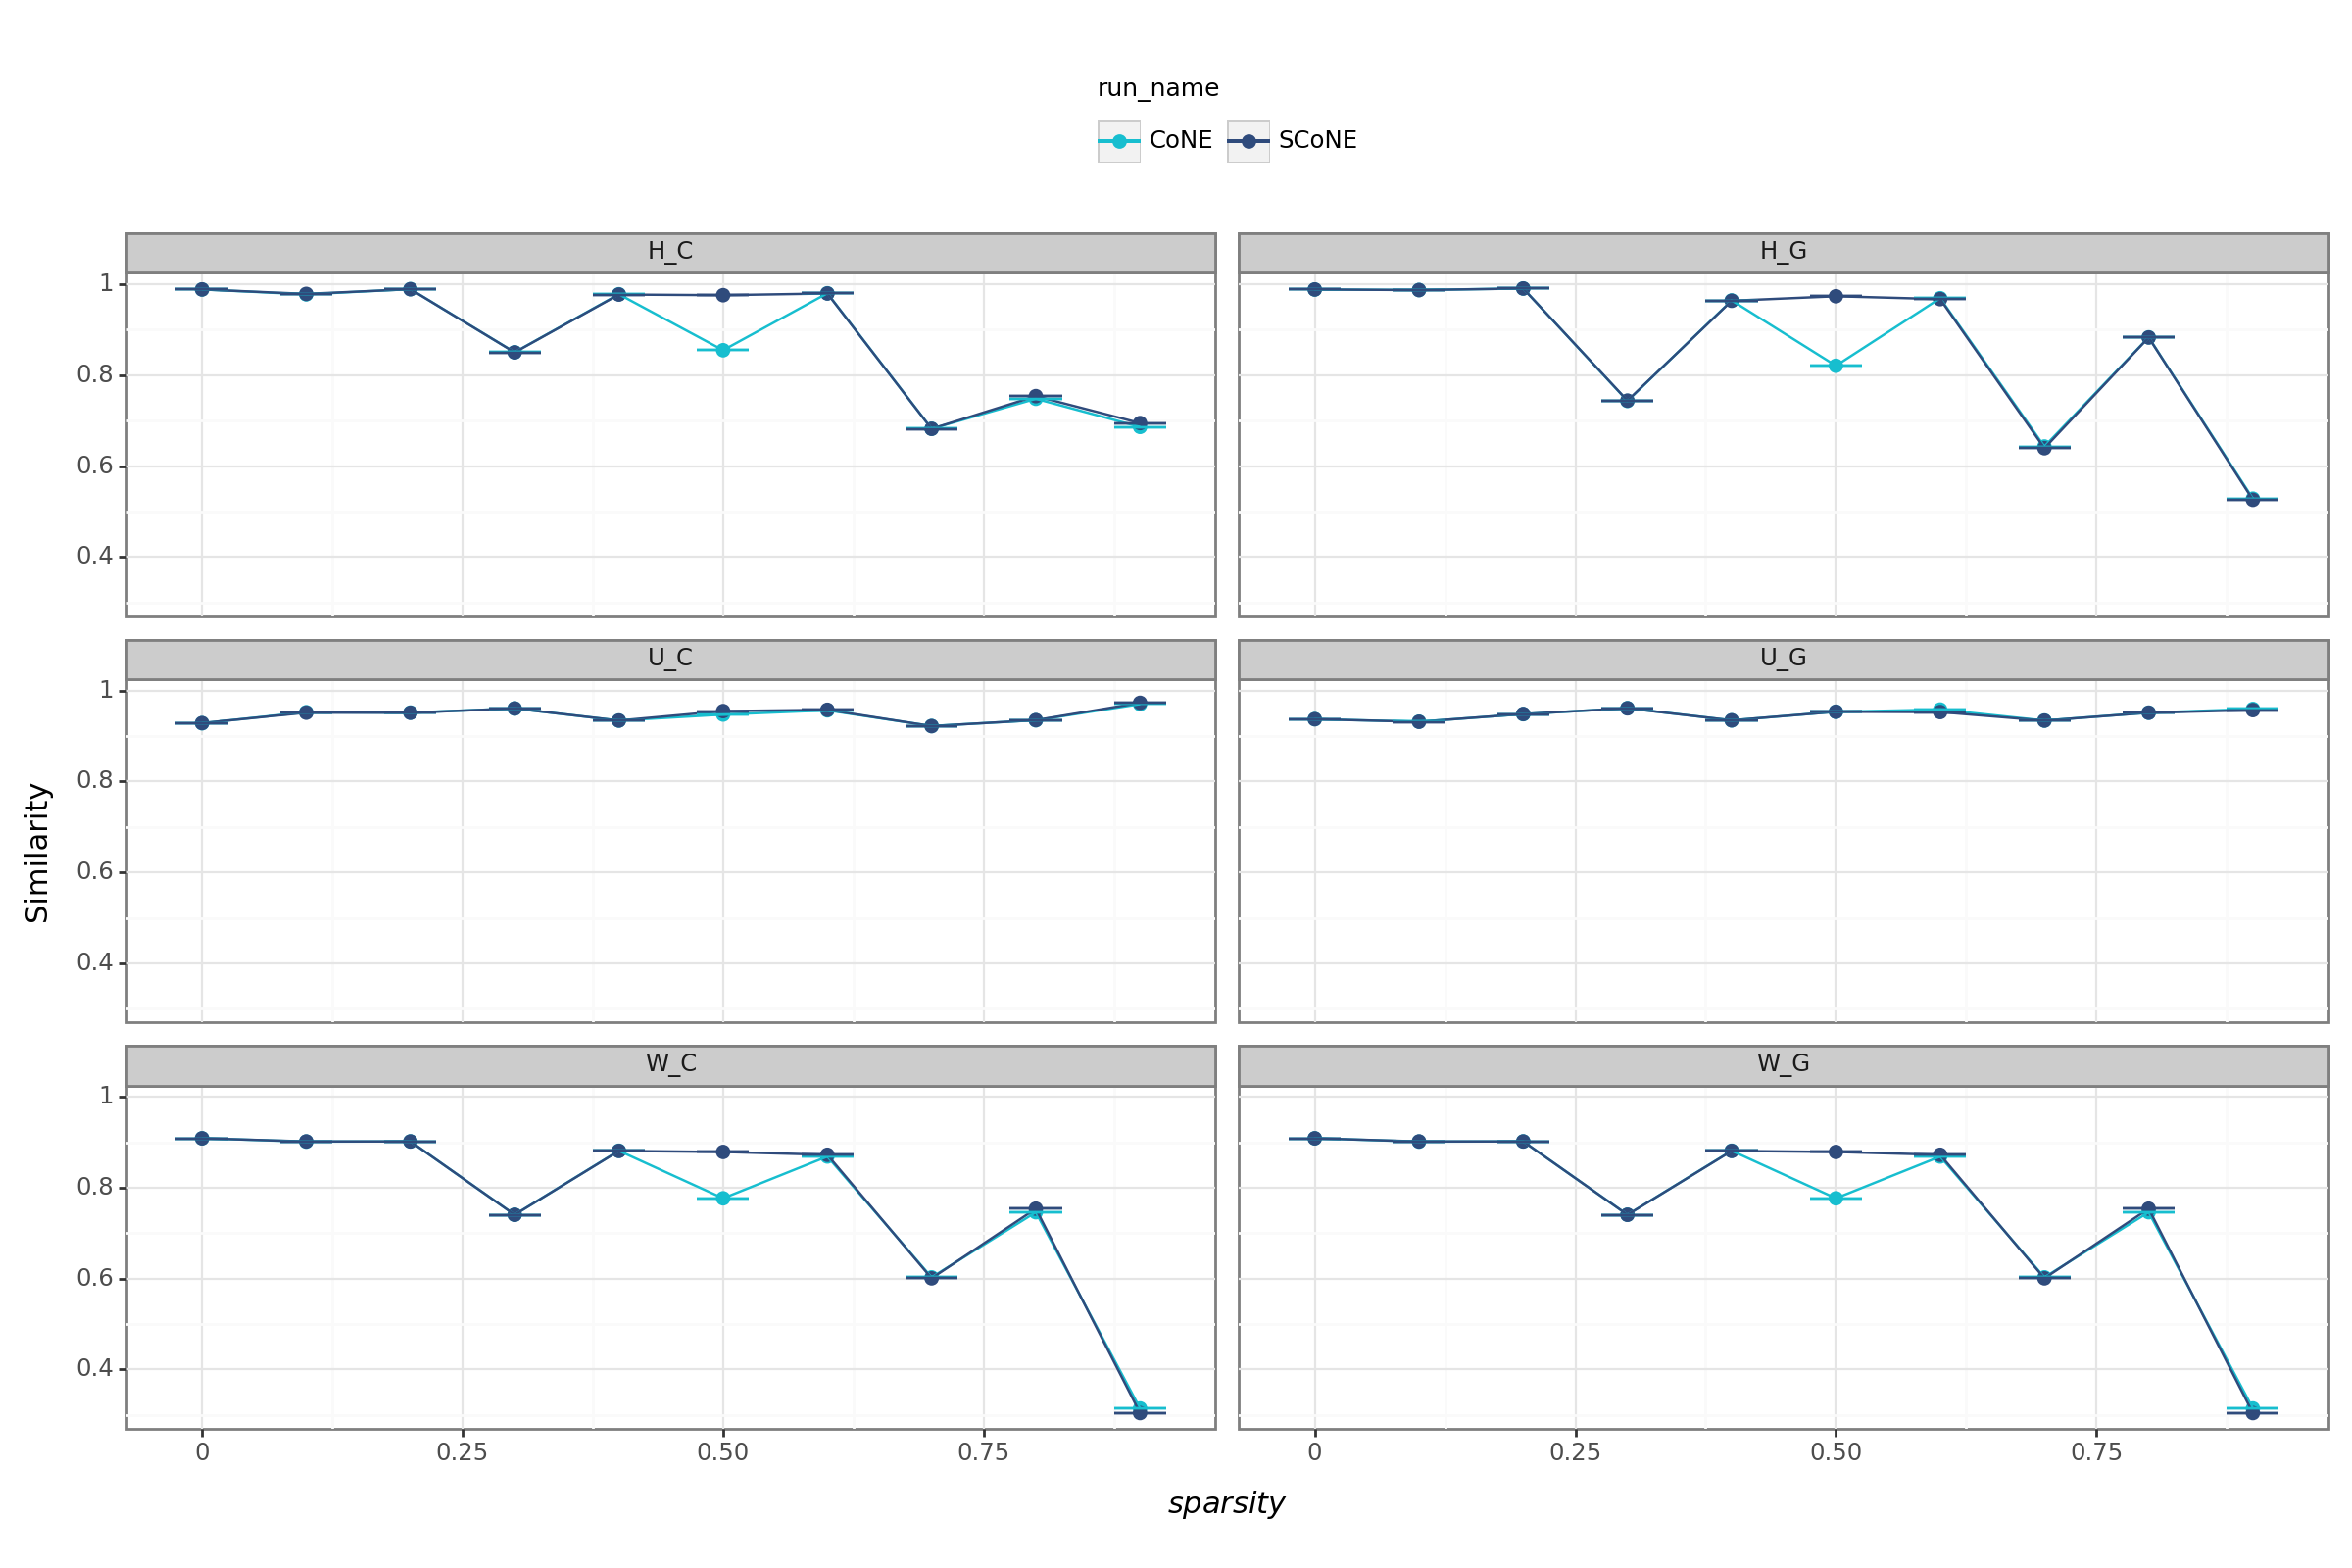

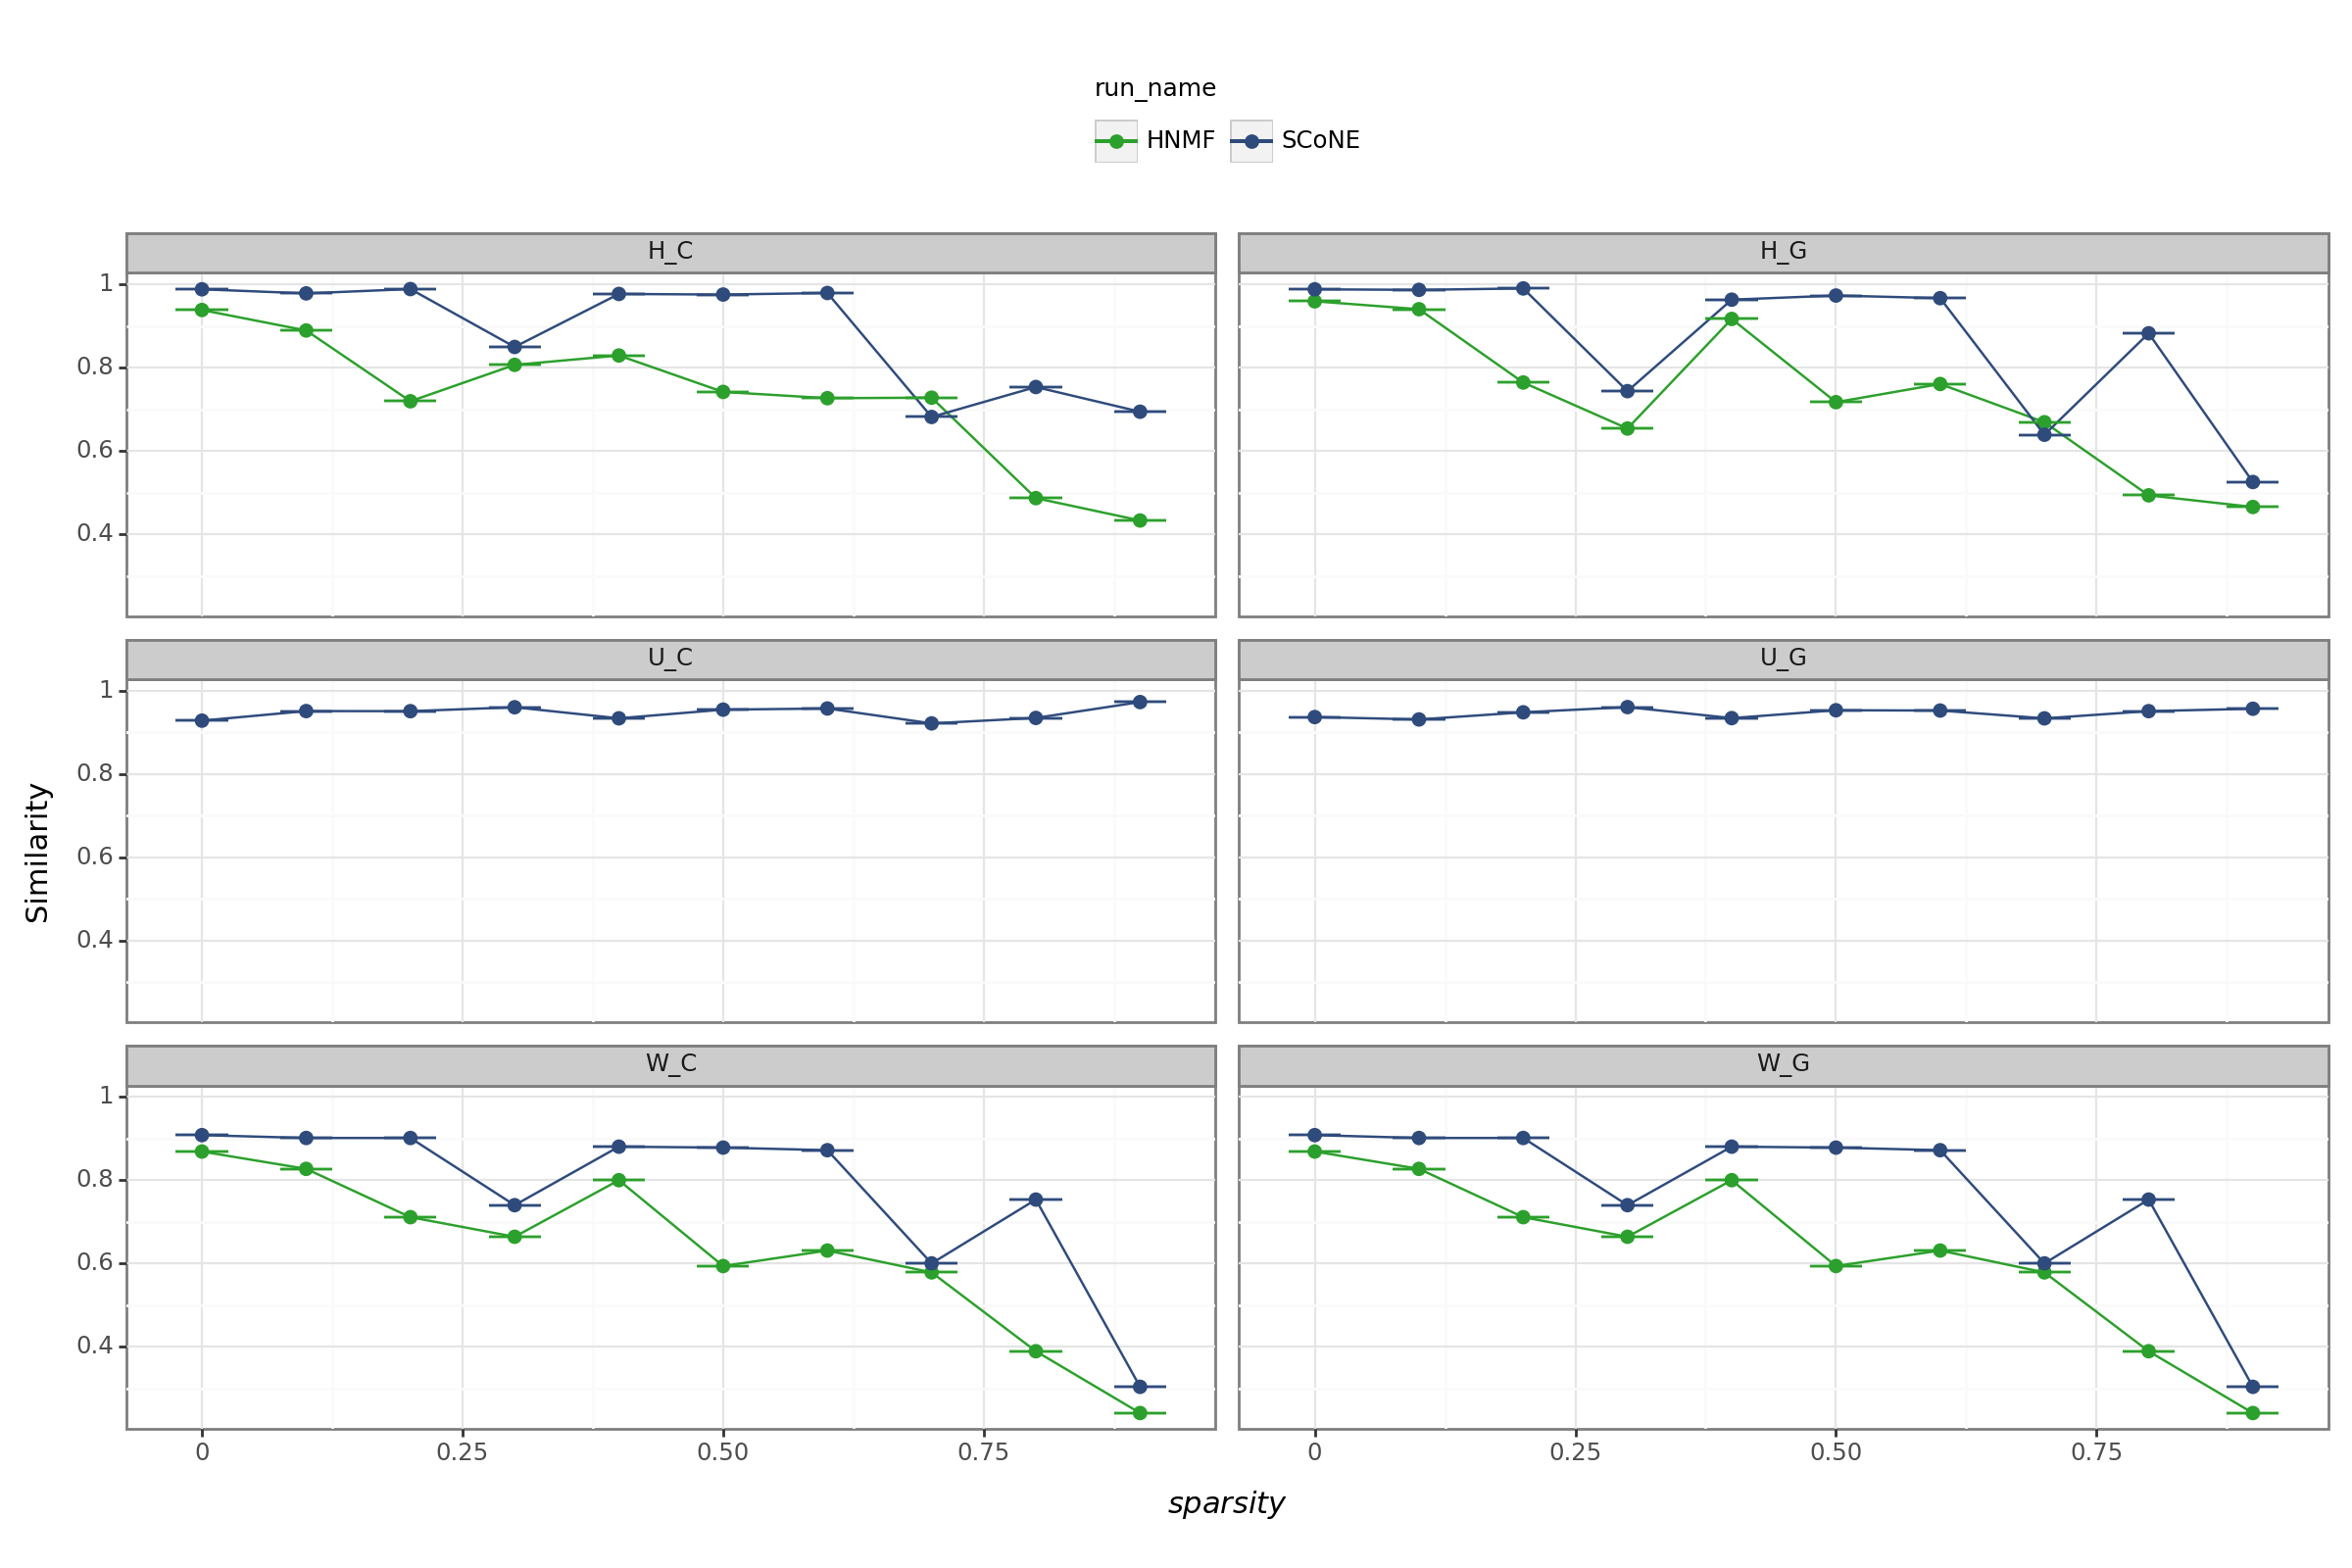

In [4]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/sparsity_summary.csv',index_col=0)
summary = summary[~((summary['run_name']=='HNMF')&(summary['factor_matrix'].str.startswith('U')))]
graph_plots(summary[summary['sparsity']<1],"sparsity",r'$sparsity$')

In [31]:
df = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/sparsity_all_tuning_results.csv')
df = df[df['sparsity']!=1].copy()
df['mean_lambdas'] = df[['lambda_W','lambda_H_G','lambda_H_C']].mean(axis=1)
idx = df.groupby(['run_name','sparsity'])["tuning_loss"].idxmin()
best = (
    df.loc[idx, df.columns]
    .reset_index(drop=True)
)

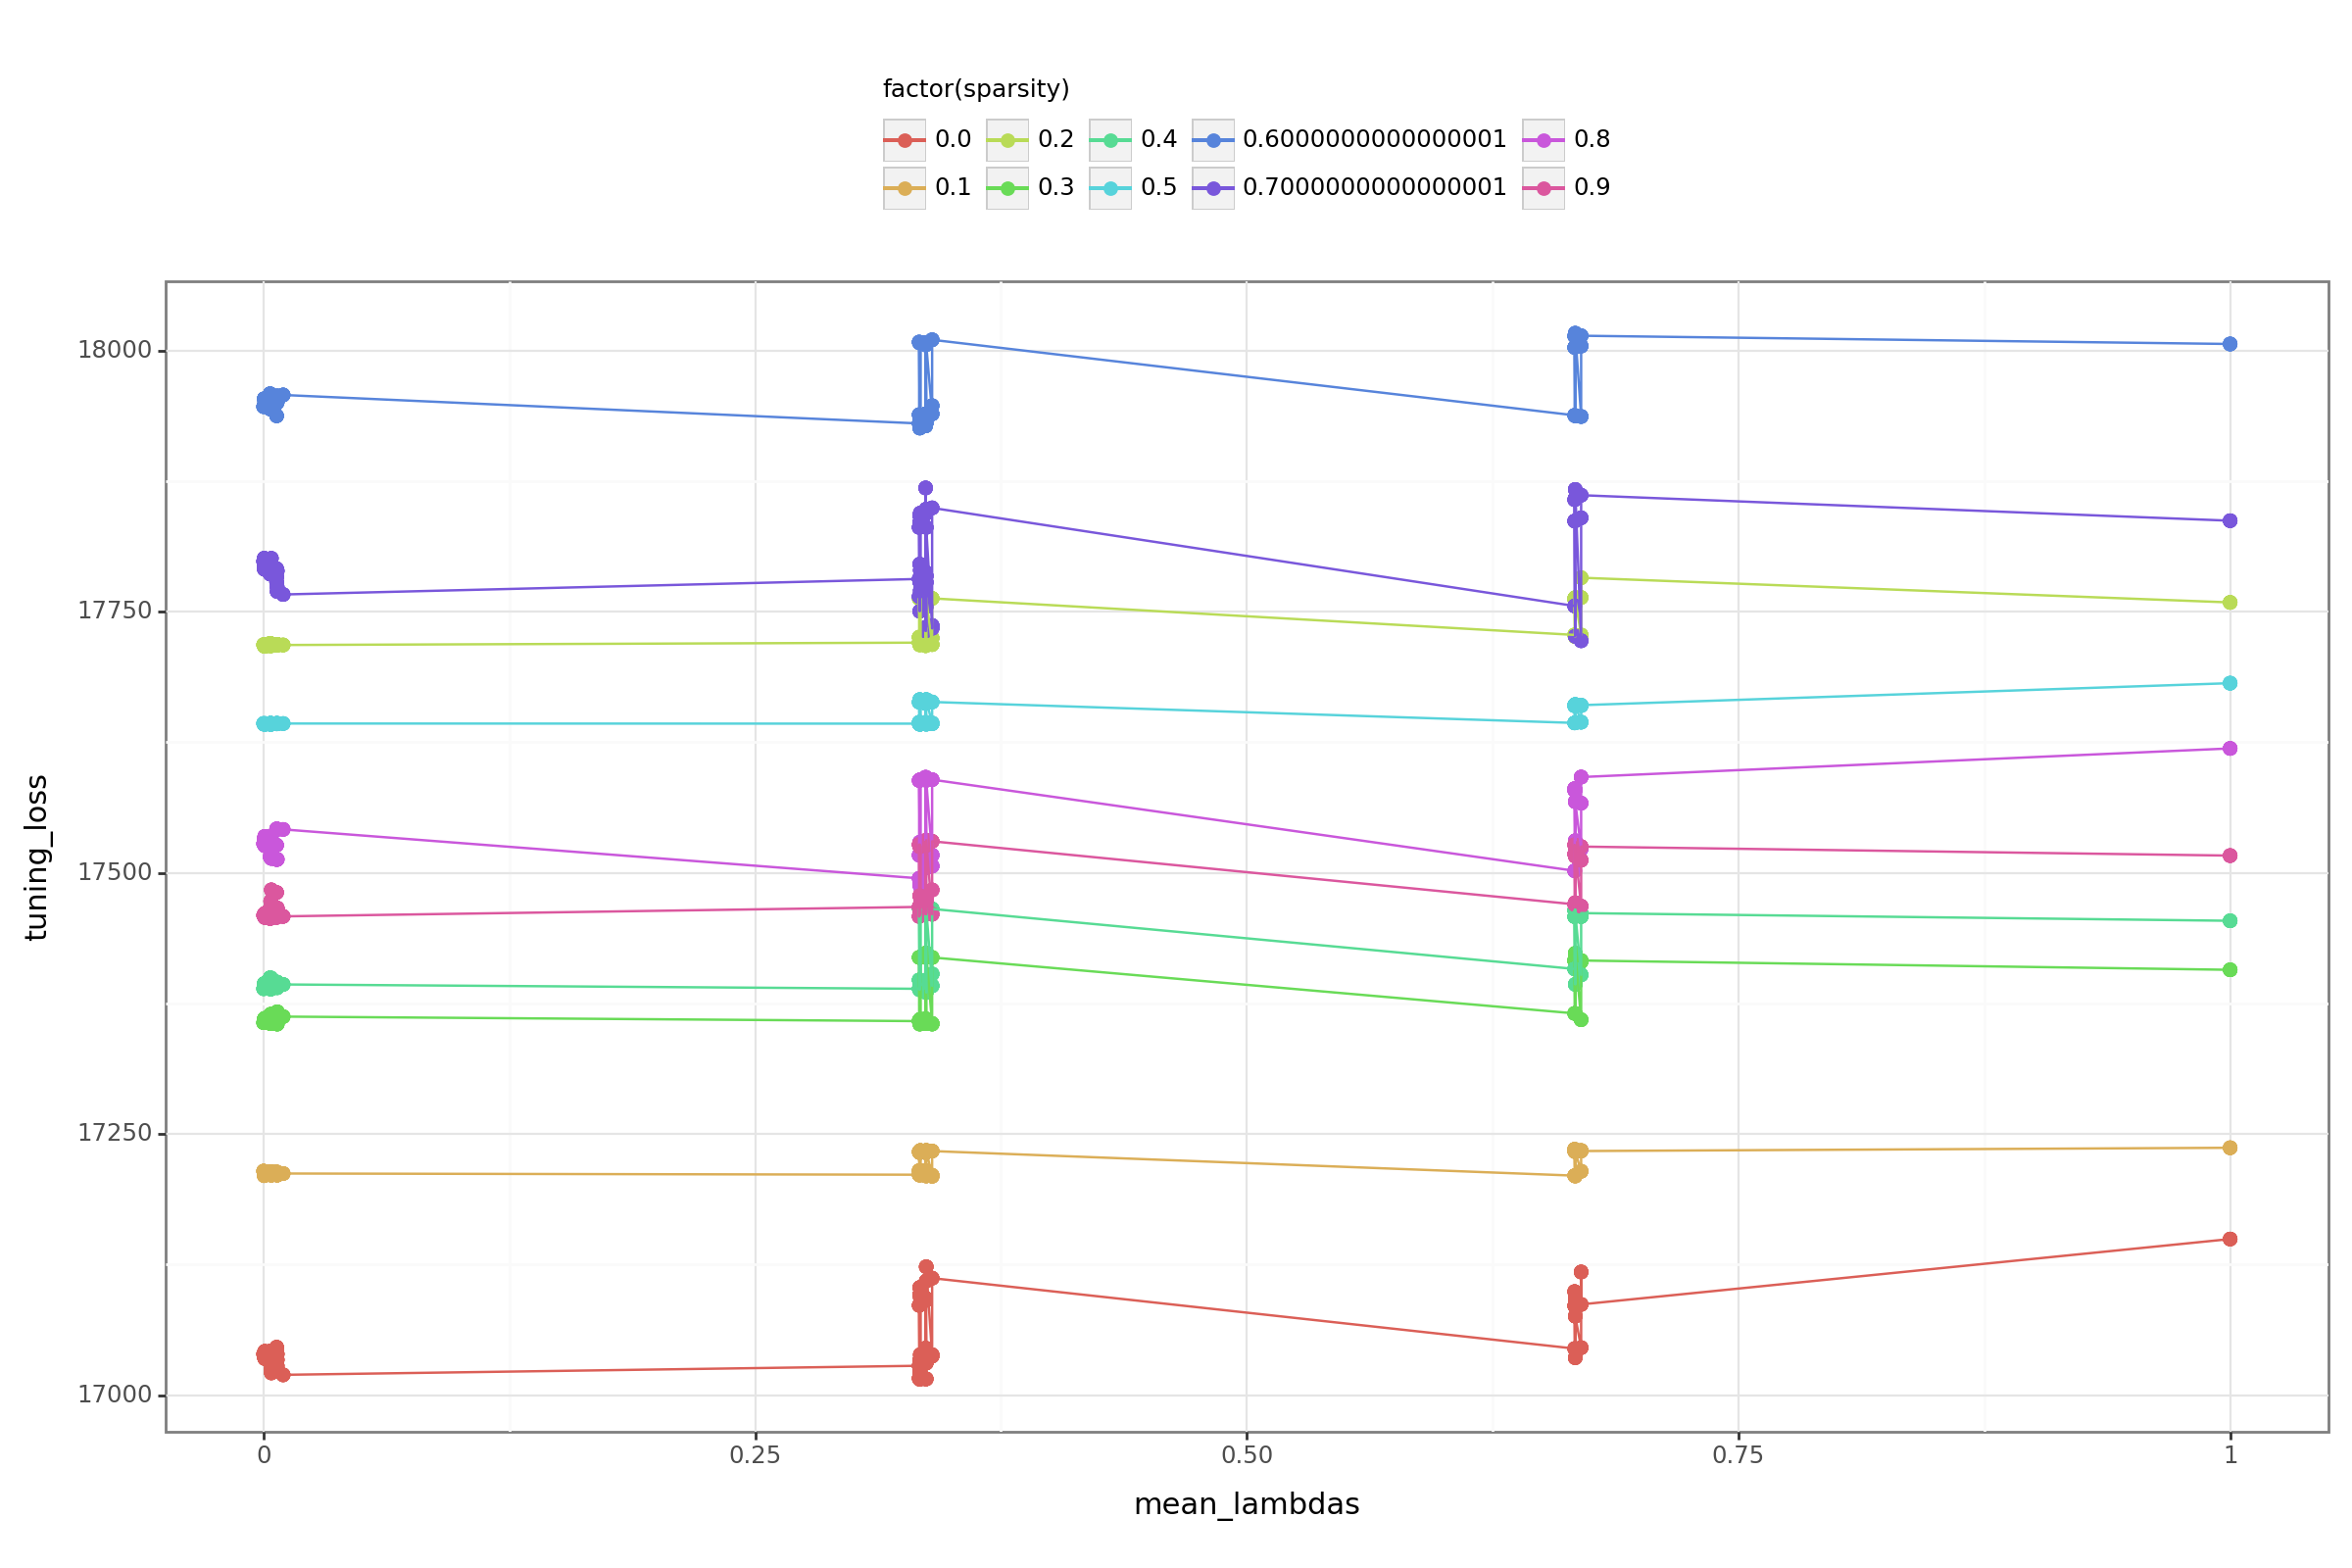

In [32]:
p = (
    ggplot(df, aes("mean_lambdas", "tuning_loss", color='factor(sparsity)',group='sparsity'))
    + geom_point(size=2)
    + geom_line()
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)

In [7]:
all_loss_functions

,epoch,total_loss,G_loss,C_loss,G_plus_C_loss,regularization,W_norm,H_G_norm,U_G_norm,H_C_norm,U_C_norm,W_sparsity,H_G_sparsity,U_G_sparsity,H_C_sparsity,U_C_sparsity,lambda,sparsity
0,0,18267.974873,9068.344721,9199.538870,18267.883591,0.091282,30.914487,5.752705,5.602573,5.420485,5.804315,25.466667,11.666667,0.0,6.666667,5.0,0.0001,0.0
1,1,17849.648343,8761.509530,9088.045821,17849.555352,0.092991,31.072881,6.014611,5.512252,5.440766,5.969185,22.066667,15.000000,5.0,11.666667,3.0,0.0001,0.0
2,2,17643.941711,8637.015234,9006.833068,17643.848302,0.093409,31.280448,6.363932,5.457831,5.566096,6.093349,21.133333,18.333333,7.0,15.000000,8.0,0.0001,0.0
3,3,17511.173530,8533.921339,8977.157301,17511.078640,0.094889,31.430094,6.437847,5.498896,5.544935,6.225352,17.733333,21.666667,9.0,18.333333,10.0,0.0001,0.0
4,4,17382.552267,8461.628799,8920.827809,17382.456608,0.095659,31.762652,6.573592,5.544353,5.592581,6.281509,17.266667,25.000000,12.0,18.333333,12.0,0.0001,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16,16,27619.271576,10162.812881,10003.366292,20166.179173,7453.092403,1.944463,3.498428,10.577833,3.235956,10.615014,79.266667,5.000000,0.0,1.666667,0.0,100.0000,0.9
17,17,27588.322249,10162.807725,10003.324815,20166.132539,7422.189710,1.929610,3.498428,10.578563,3.235956,10.615027,79.466667,5.000000,0.0,1.666667,0.0,100.0000,0.9
18,18,27587.991630,10162.806940,10003.302259,20166.109199,7421.882431,1.929462,3.498428,10.579865,3.235956,10.615093,79.466667,5.000000,0.0,1.666667,0.0,100.0000,0.9
19,19,27584.903962,10162.806712,10003.287640,20166.094352,7418.809610,1.927979,3.498428,10.579414,3.235956,10.615217,79.466667,5.000000,0.0,1.666667,0.0,100.0000,0.9


In [11]:
all_loss_functions[(all_loss_functions['sparsity']==0.4)&(all_loss_functions['lambda']==1)]

,epoch,total_loss,G_loss,C_loss,G_plus_C_loss,regularization,W_norm,H_G_norm,U_G_norm,H_C_norm,U_C_norm,W_sparsity,H_G_sparsity,U_G_sparsity,H_C_sparsity,U_C_sparsity,lambda,sparsity
0,0,19647.721802,9509.716595,9452.975905,18962.692500,685.029303,23.404728,6.817668,5.892678,5.482081,6.477032,32.200000,13.333333,3.0,6.666667,2.0,1.0,0.4
1,1,18964.151249,9058.890549,9294.062630,18352.953180,611.198070,20.490022,7.315185,5.952726,6.387295,6.762282,29.866667,11.666667,3.0,11.666667,4.0,1.0,0.4
2,2,18685.660859,8912.724799,9165.962045,18078.686844,606.974015,19.983686,7.990578,5.910430,6.811838,6.979692,24.200000,23.333333,7.0,23.333333,4.0,1.0,0.4
3,3,18444.972340,8787.423116,9056.535387,17843.958503,601.013838,19.535758,8.629382,5.883084,7.240744,7.024025,23.933333,25.000000,9.0,31.666667,6.0,1.0,0.4
4,4,18350.158595,8725.217819,9029.408348,17754.626166,595.532429,19.155193,9.035656,5.931059,7.549599,7.067422,22.600000,28.333333,15.0,31.666667,7.0,1.0,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,17837.742394,8394.251371,8976.300028,17370.551399,467.190995,13.262529,14.808866,6.428162,11.765870,7.755392,21.800000,41.666667,25.0,35.000000,15.0,1.0,0.4
96,96,17837.302899,8393.808163,8976.364244,17370.172408,467.130491,13.245661,14.872169,6.418494,11.765870,7.758109,21.800000,41.666667,26.0,35.000000,15.0,1.0,0.4
97,97,17836.775967,8393.532138,8976.534487,17370.066625,466.709343,13.228099,14.872169,6.421078,11.767949,7.760598,21.733333,41.666667,26.0,35.000000,14.0,1.0,0.4
98,98,17836.306231,8393.326401,8976.502102,17369.828503,466.477728,13.211073,14.872154,6.421311,11.818008,7.757499,21.800000,41.666667,25.0,35.000000,15.0,1.0,0.4


In [13]:
all_loss_functions[all_loss_functions['sparsity']==0.4]

,epoch,total_loss,G_loss,C_loss,G_plus_C_loss,regularization,W_norm,H_G_norm,U_G_norm,H_C_norm,U_C_norm,W_sparsity,H_G_sparsity,U_G_sparsity,H_C_sparsity,U_C_sparsity,lambda,sparsity
0,0,18755.161497,9289.225958,9465.864618,18755.090576,0.070921,24.864778,5.978127,6.053345,5.148216,6.632962,32.933333,16.666667,1.0,8.333333,1.0,0.0001,0.4
1,1,18200.166240,8961.768837,9238.326903,18200.095740,0.070500,24.360373,6.296245,5.865416,5.487137,6.693167,26.666667,20.000000,5.0,15.000000,4.0,0.0001,0.4
2,2,17982.635408,8828.913687,9153.647484,17982.561171,0.074236,25.213410,6.373317,5.915044,5.258094,7.177857,23.000000,23.333333,8.0,31.666667,6.0,0.0001,0.4
3,3,17802.487307,8728.020125,9074.389698,17802.409823,0.077484,26.461577,6.428598,5.960432,5.326373,7.194420,21.200000,25.000000,11.0,26.666667,6.0,0.0001,0.4
4,4,17696.350247,8683.155524,9013.114779,17696.270303,0.079944,27.229867,6.450476,6.039000,5.326455,7.194398,20.200000,31.666667,15.0,30.000000,9.0,0.0001,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,20,30538.637826,10559.171379,10419.572916,20978.744295,9559.893531,3.347199,2.525788,13.147433,2.764451,12.805586,69.133333,11.666667,0.0,8.333333,0.0,100.0000,0.4
21,21,30084.437662,10559.131361,10419.423797,20978.555158,9105.882505,3.165403,2.525788,13.170267,2.764451,12.832481,70.133333,11.666667,0.0,8.333333,0.0,100.0000,0.4
22,22,29644.519303,10559.009272,10419.342590,20978.351862,8666.167442,2.987567,2.525788,13.192136,2.764451,12.858518,71.200000,11.666667,0.0,8.333333,0.0,100.0000,0.4
23,23,29222.606090,10558.971144,10419.292279,20978.263423,8244.342668,2.813848,2.525788,13.213349,2.764451,12.883603,72.133333,11.666667,0.0,8.333333,0.0,100.0000,0.4


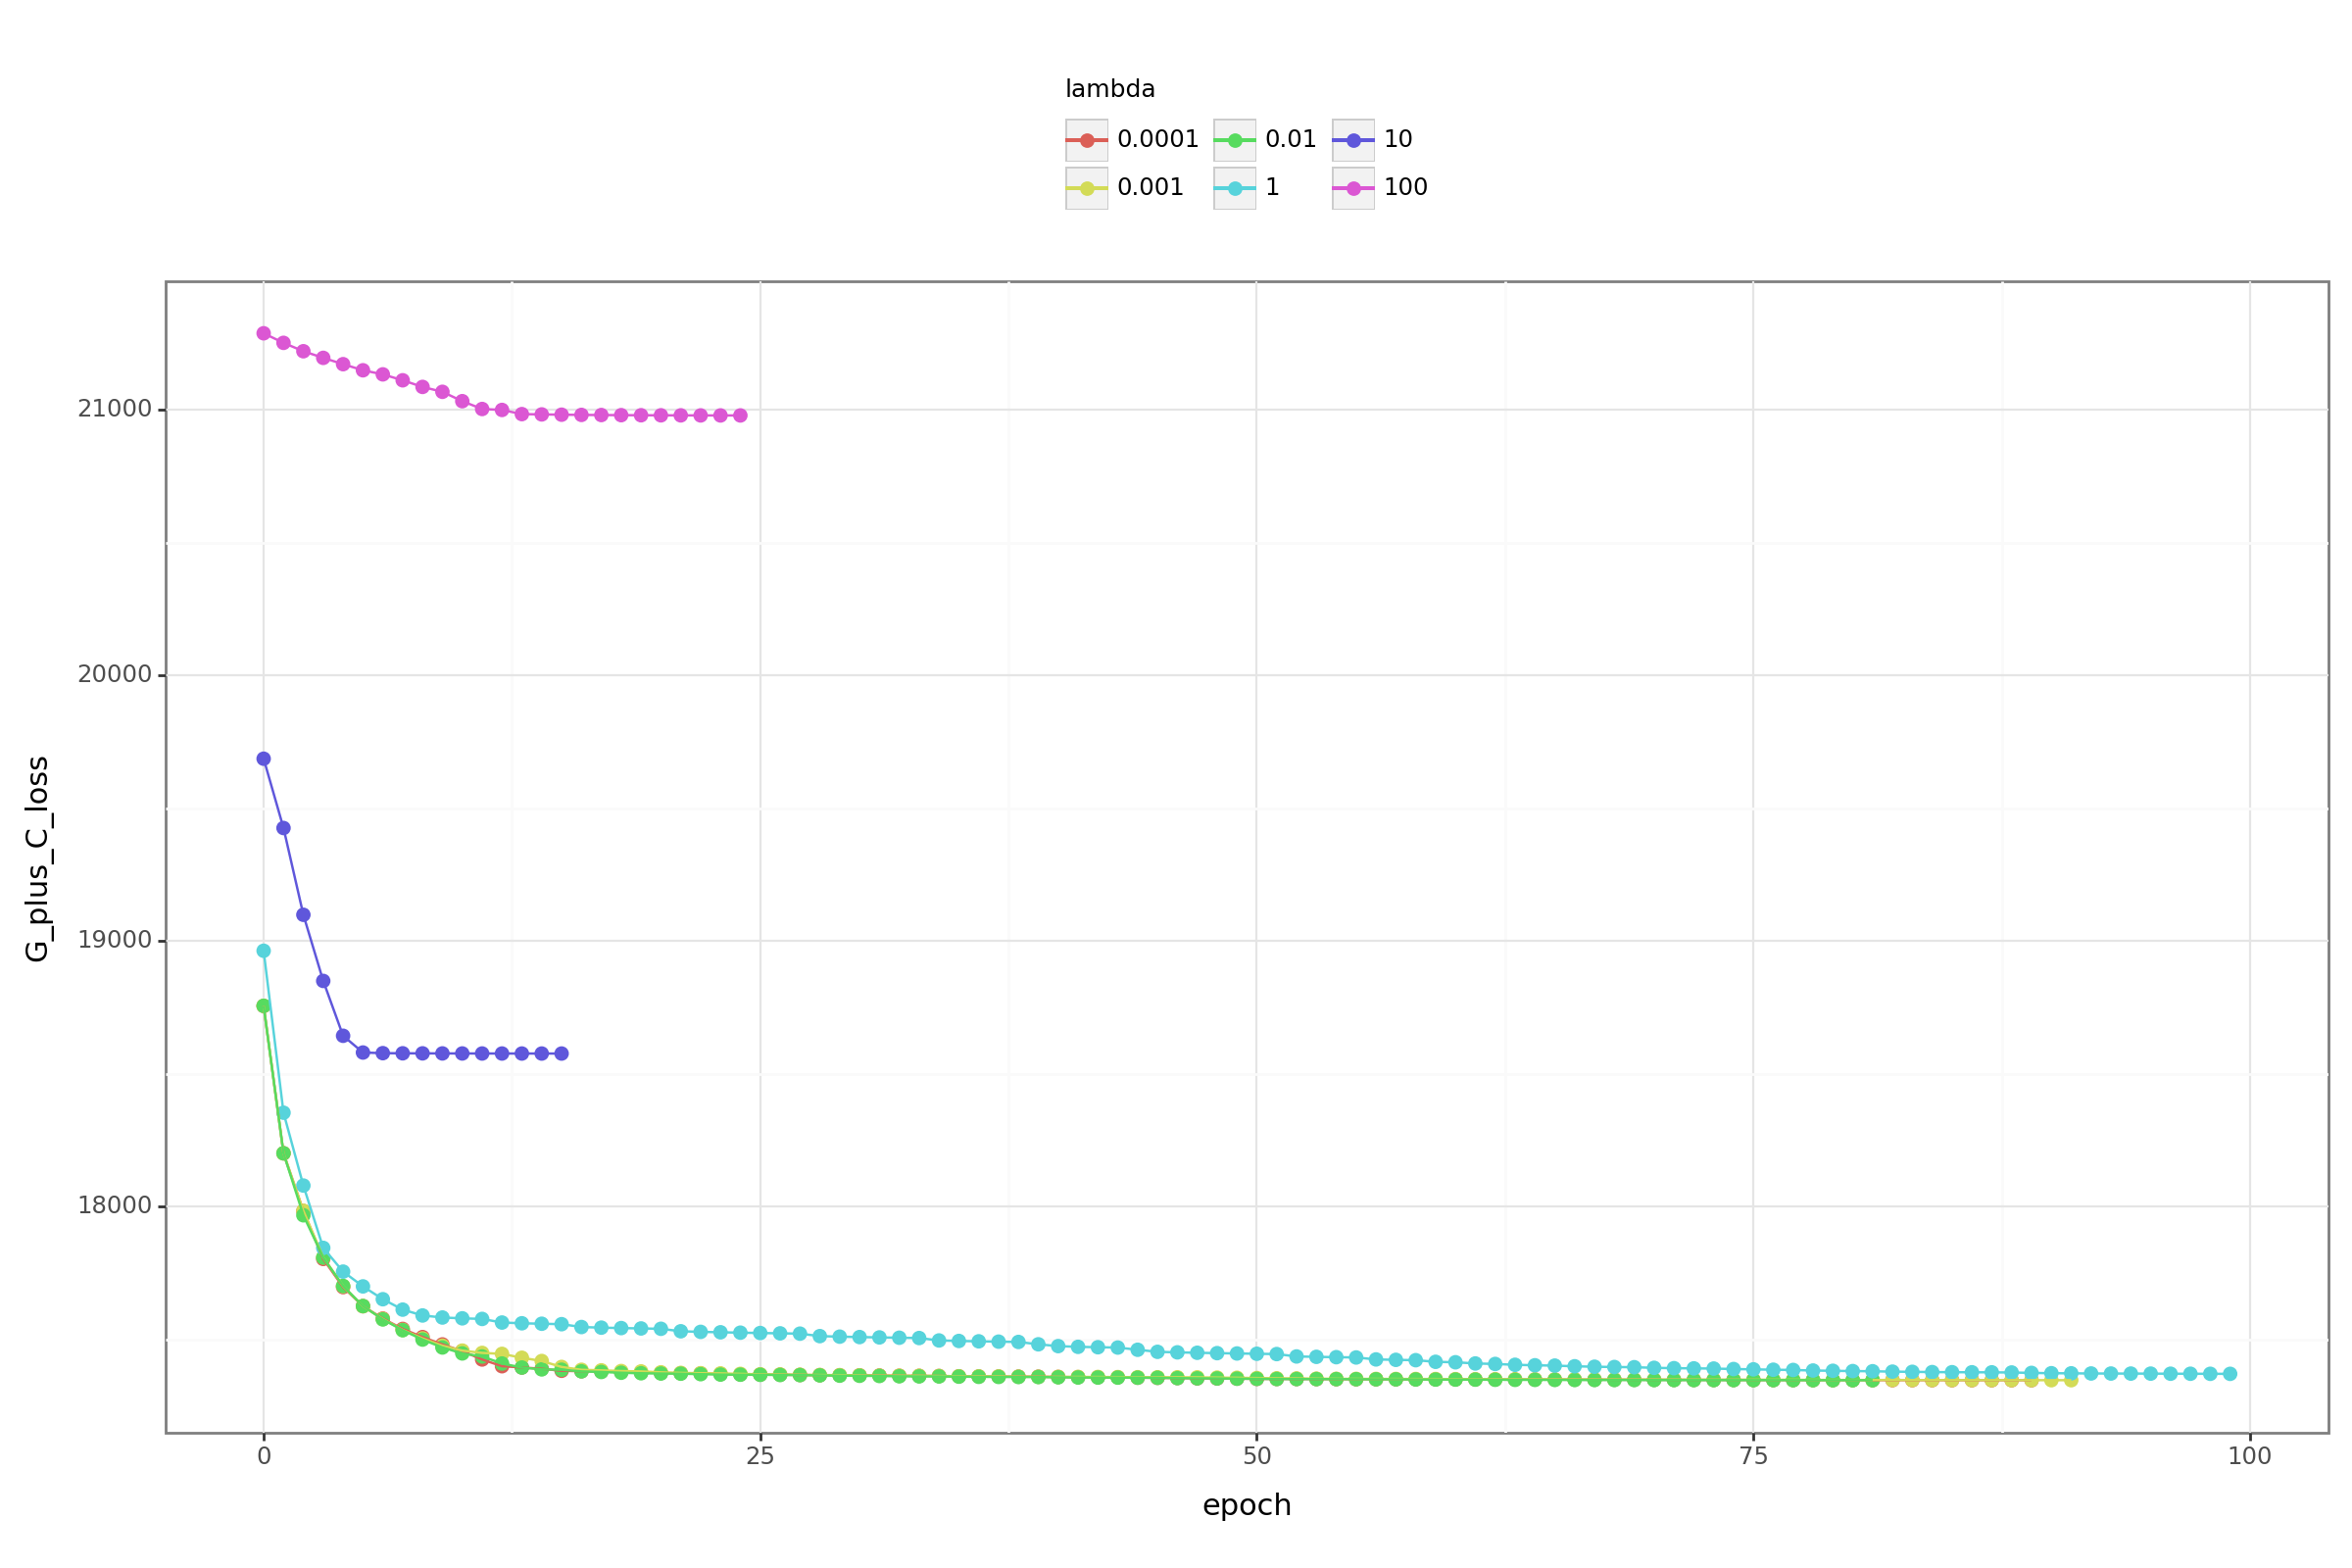

In [17]:
import json
import pandas as pd
import numpy as np
from plotnine import *
all_loss_functions = []
for lambda_val in [1e-4,1e-3,1e-2,1,10,100]:
    for sparsity in np.arange(0,1,0.1):
        with open(f"/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/models/loss_function_lambdaval_{lambda_val}_sparsity_{sparsity}.json","r") as f:
            loss_function = json.load(f)
            loss_function_df = pd.DataFrame(loss_function).reset_index(names='epoch')
            loss_function_df['lambda'] = str(lambda_val)
            loss_function_df['sparsity'] = sparsity
            all_loss_functions.append(loss_function_df)

all_loss_functions = pd.concat(all_loss_functions)
p = (
    ggplot(all_loss_functions[all_loss_functions['sparsity']==0.4], aes("epoch", "G_plus_C_loss", color='lambda',group='lambda'))
    + geom_point(size=2)
    + geom_line()
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)

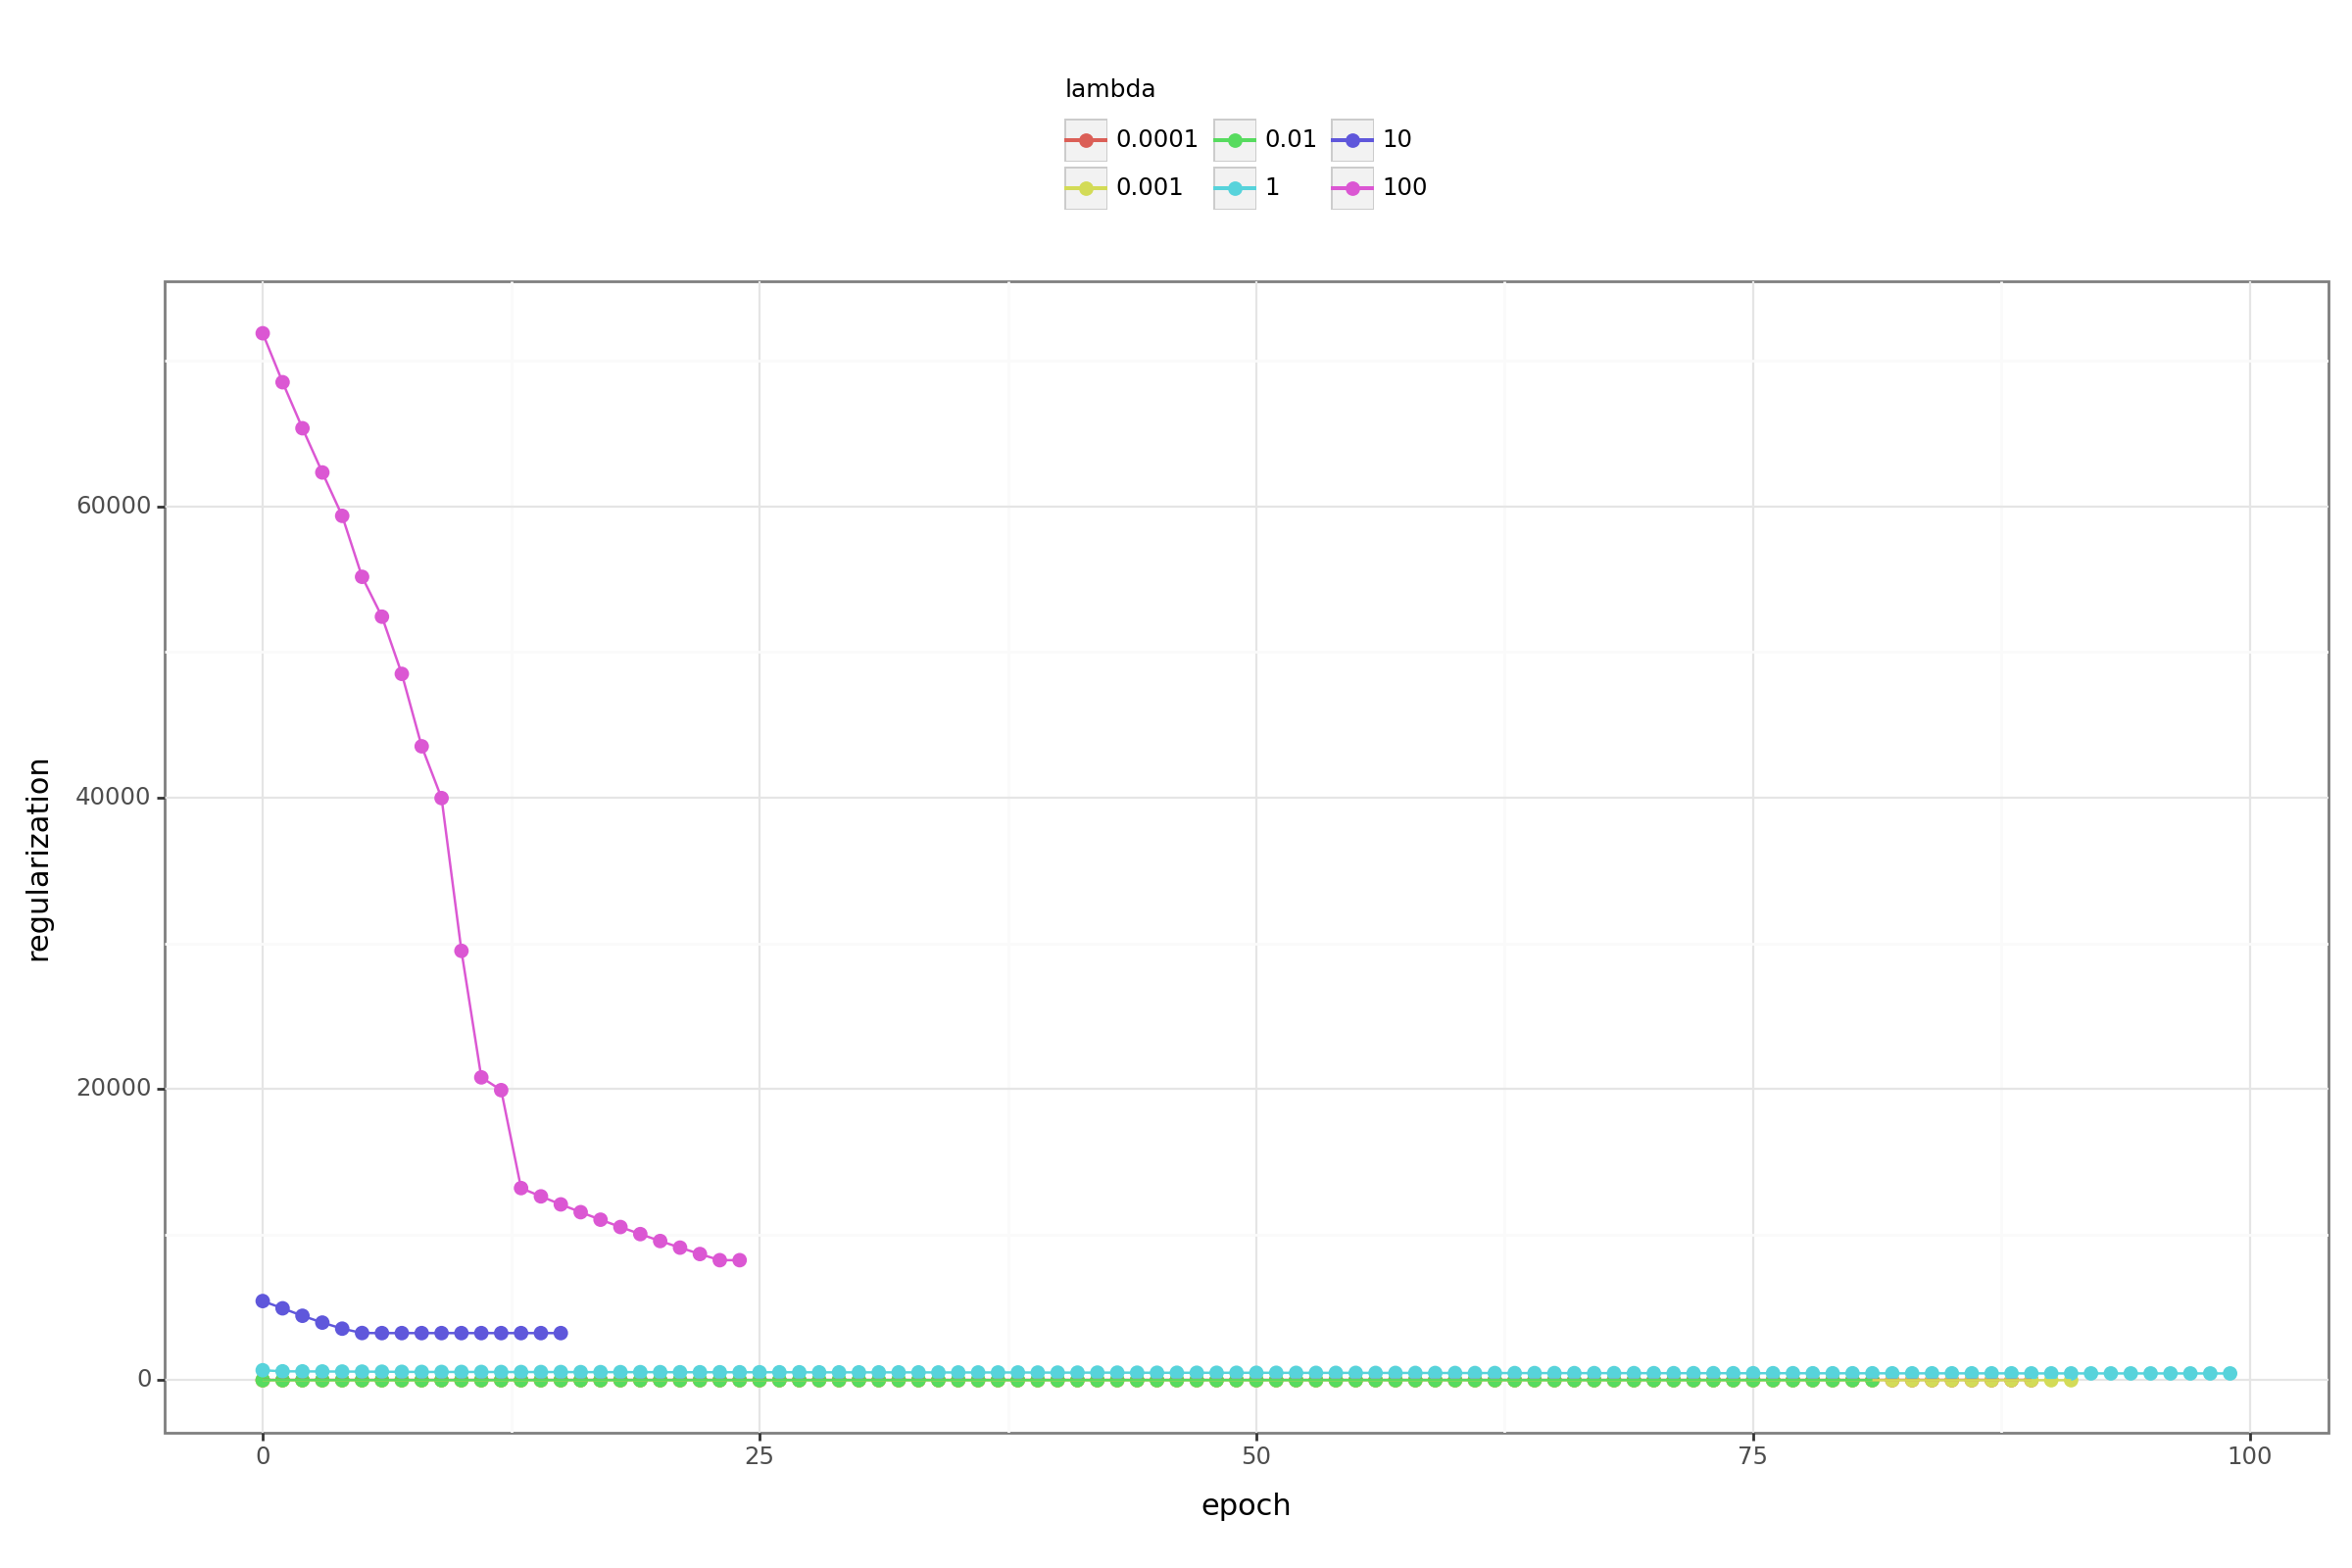

In [18]:
p = (
    ggplot(all_loss_functions[all_loss_functions['sparsity']==0.4], aes("epoch", "regularization", color='lambda',group='lambda'))
    + geom_point(size=2)
    + geom_line()
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)

In [37]:
loss_function_df

,total_loss,G_loss,C_loss,G_plus_C_loss,regularization,W_norm,H_G_norm,U_G_norm,H_C_norm,U_C_norm,W_sparsity,H_G_sparsity,U_G_sparsity,H_C_sparsity,U_C_sparsity
0,103174.596364,10810.302584,10509.751856,21320.054440,81854.541924,22.257549,3.948324,9.229665,3.426068,9.496782,0.000000,1.666667,0.0,3.333333,0.0
1,98465.364718,10784.241851,10495.933884,21280.175735,77185.188983,21.220205,3.805494,9.786687,3.356371,9.895230,0.000000,5.000000,0.0,5.000000,0.0
2,95262.018961,10763.533686,10485.341414,21248.875100,74013.143861,20.536303,3.662303,10.262550,3.286410,10.235796,0.000000,6.666667,0.0,6.666667,0.0
3,92015.740440,10744.940308,10470.764945,21215.705252,70800.035187,19.859332,3.520426,10.708932,3.149087,10.651095,1.266667,8.333333,0.0,8.333333,0.0
4,88887.209591,10728.324932,10462.248642,21190.573574,67696.636017,19.189805,3.379976,11.132414,3.080618,10.967966,2.800000,8.333333,0.0,8.333333,0.0
5,85750.359106,10712.688583,10450.044037,21162.732619,64587.626487,18.527789,3.241189,11.534246,2.946067,11.347633,4.933333,8.333333,0.0,8.333333,0.0
6,82745.931806,10698.115252,10442.514689,21140.629941,61605.301865,17.873581,3.104304,11.913653,2.879234,11.633292,7.533333,8.333333,0.0,8.333333,0.0
7,79803.916471,10684.501848,10435.309112,21119.810959,58684.105511,17.227120,2.969582,12.270217,2.812970,11.896186,9.000000,10.000000,0.0,10.000000,0.0
8,76919.868170,10672.087828,10428.631560,21100.719388,55819.148782,16.588695,2.837194,12.604086,2.747369,12.144184,10.933333,11.666667,0.0,10.000000,0.0
9,72876.409924,10662.062349,10420.152136,21082.214485,51794.195439,15.646730,2.772220,12.903963,2.683056,12.433639,14.533333,15.000000,0.0,13.333333,0.0


/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 4 rows containing missing values.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:98: PlotnineWarning: geom_path: Removed 1 rows containing missing values.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_errorbar : Removed 4 rows containing missing values.


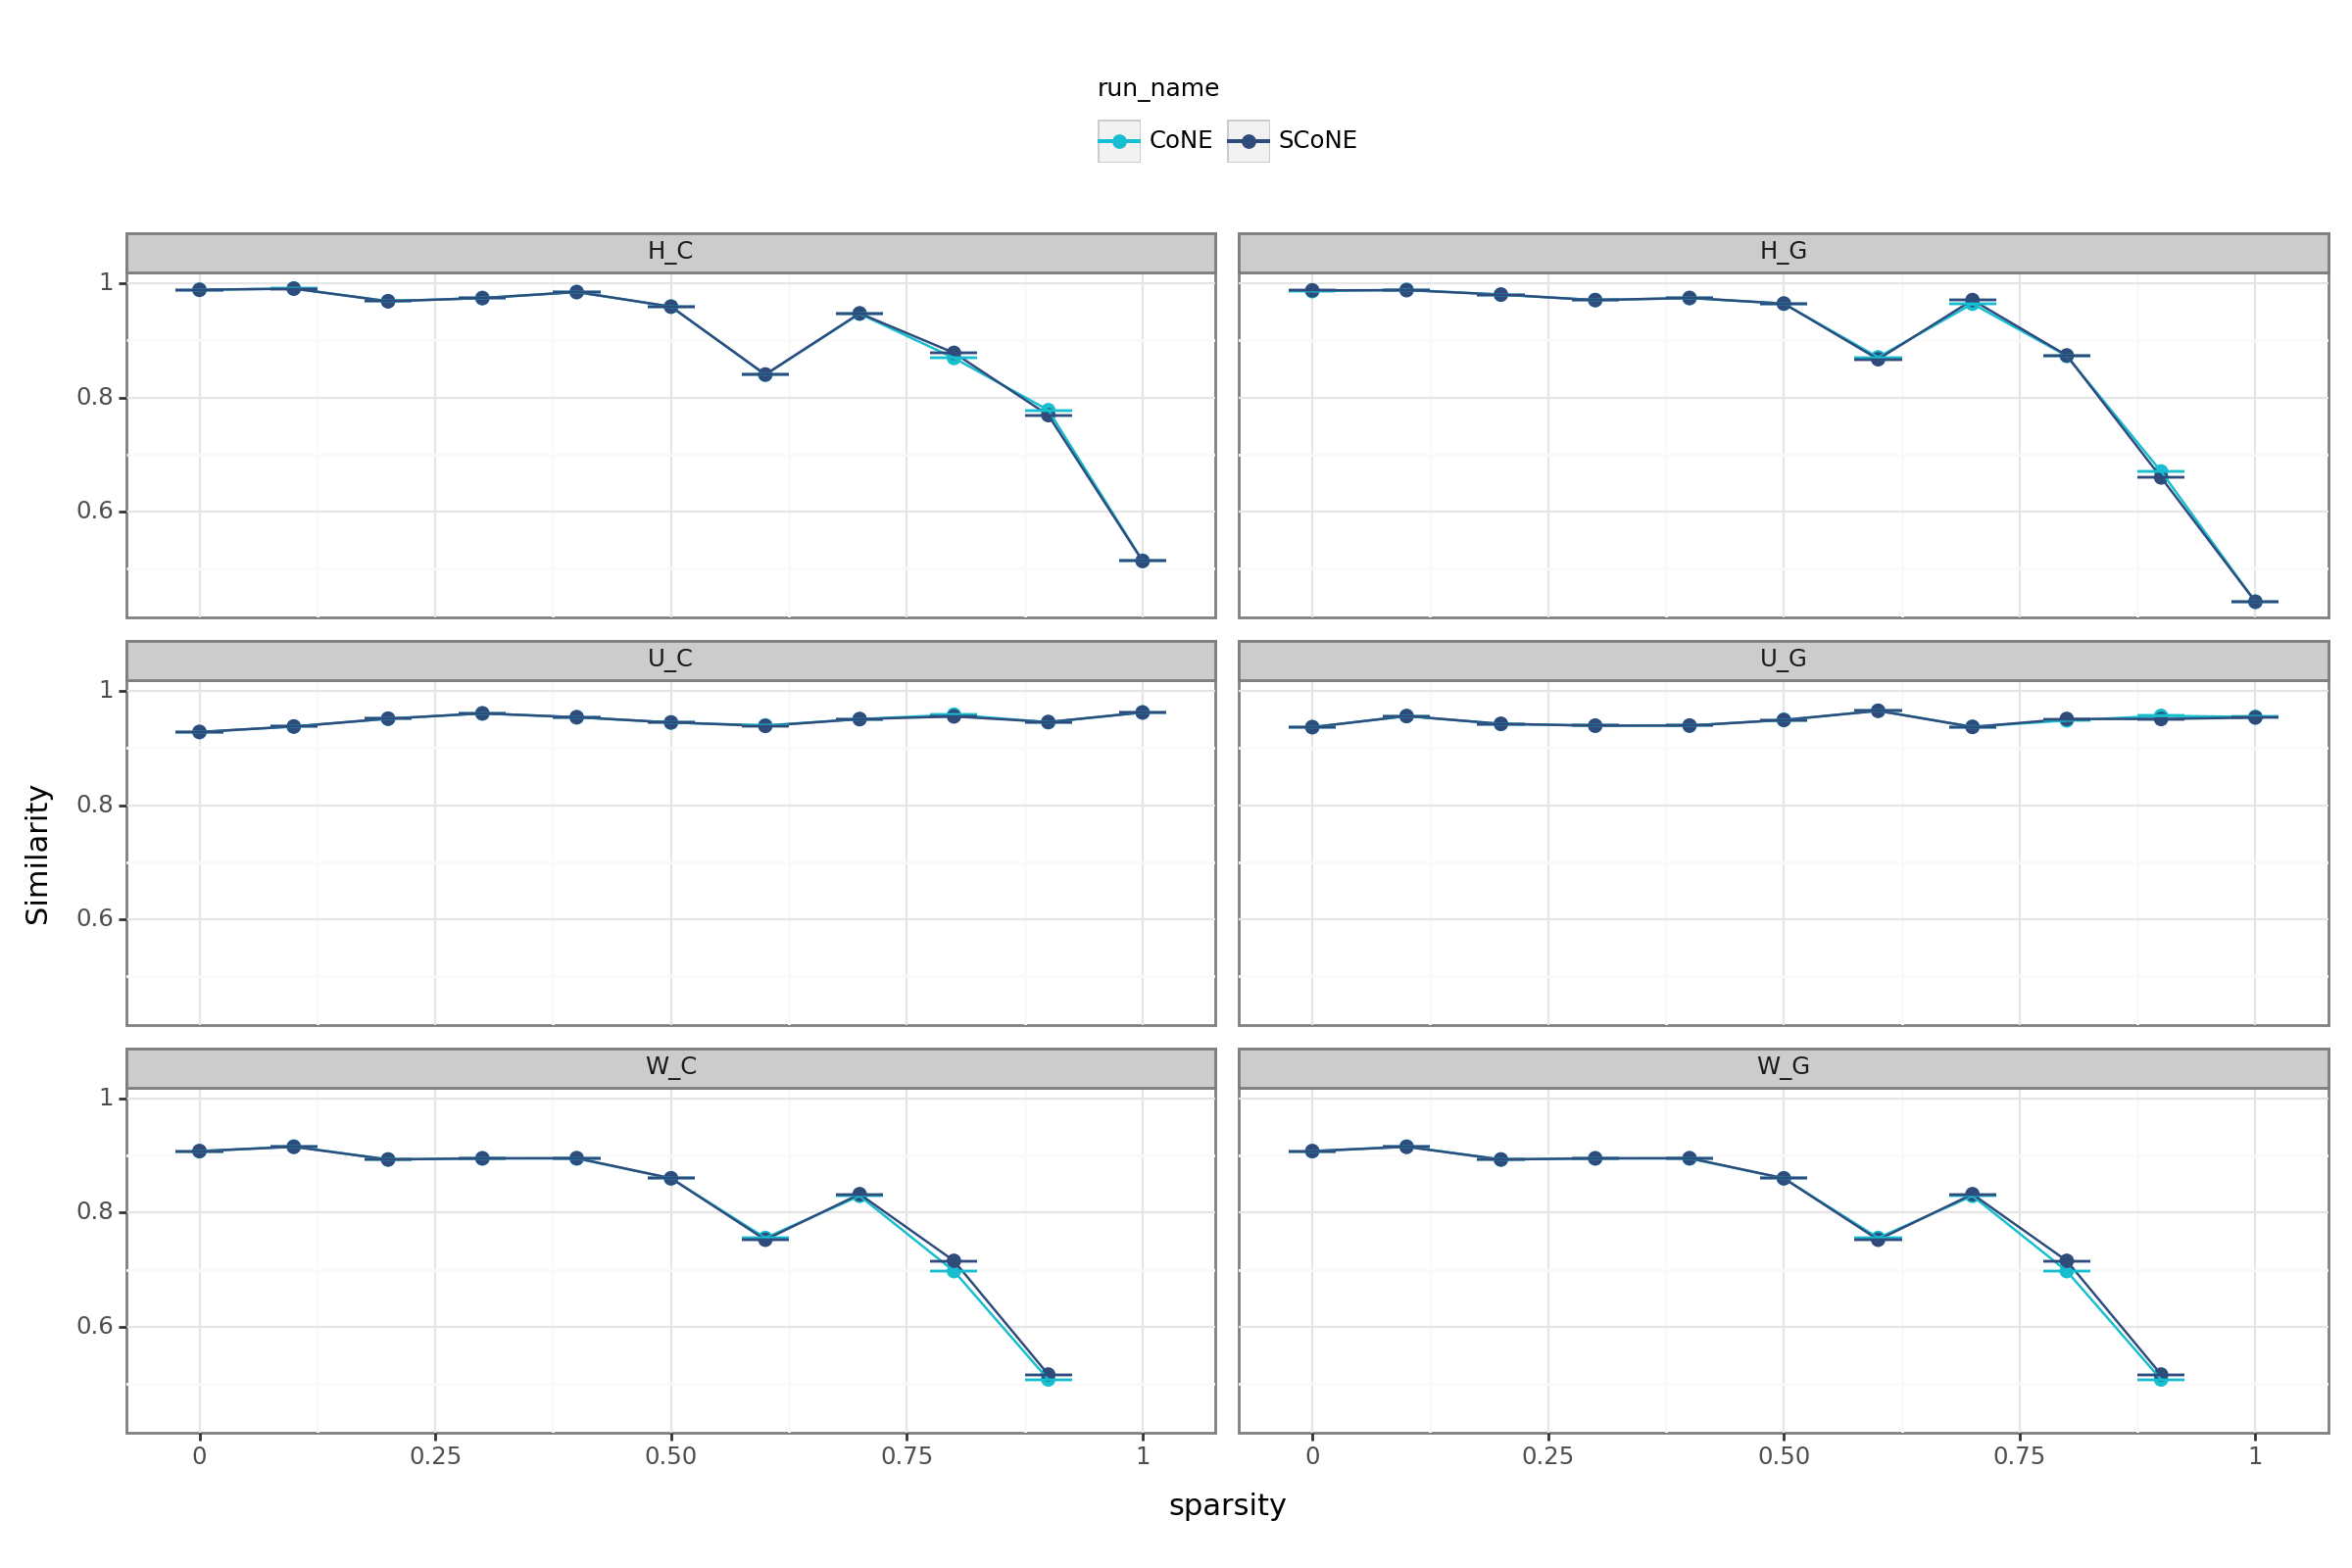

In [8]:
p = (
    ggplot(summary[summary['run_name'].isin(['SCoNE','CoNE'])], aes("sparsity", "mean", color='run_name', group='run_name'))
    + geom_point(size=2)
    + geom_line()
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
    + scale_color_manual(values=colors_dict)
    + facet_wrap('factor_matrix',nrow=3)
    + labs(y='Similarity',x="sparsity")
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)